# Detecção de Emoções via Ensemble Fuzzy

## Uma abordagem focada em interpretabilidade

Sistema de Inferência Nebulosa (Mamdani) que combina as probabilidades de dois classificadores —
**BERTimbau** e **Regressão Logística** — com a **polaridade léxica** do texto, produzindo uma
pertinência emocional interpretável por emoção. As três entradas são fuzzificadas em variáveis
linguísticas ancoradas no ponto de decisão τ calibrado por emoção; as regras (MAF) vêm de um método
especialista e de Wang–Mendel; a saída é auditável regra a regra.

**Origem das entradas.** As probabilidades *out-of-fold* são as produzidas pelos notebooks de
baseline **`baseline_BERT`** (BERTimbau) e **`baseline_LR`** (Regressão Logística). Nenhum modelo é
retreinado aqui: o notebook lê os caches OOF desses baselines e constrói o ensemble sobre eles. A
comparação final é feita contra esses mesmos baselines, com limiar calibrado por emoção.

In [31]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import time
import math
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("../data/treated")                 # folds: fold_k/data.parquet
N_OUTER_FOLDS = 5
TEXT_COL = "CLEAN_TEXT"

# ── Caches OOF dos baselines enviados (NÃO retreinamos nada aqui) ──
BERT_CACHE = Path("../data/out/bertimbau/cache")       # P_bertimbau_fold{k}.npy
LR_CACHE   = Path("../data/out/baseline_LR/cache")     # proba_all_{variant}_fold{k}.npy
LR_VARIANT = "nosmote"                                  # variante do LR usada no ensemble

# Métricas globais dos baselines (para a comparação final, se existirem)
BERT_METRICS = Path("../data/out/bertimbau/bertimbau_global_metrics.csv")
LR_METRICS   = Path("../data/out/baseline_LR/baseline_LR_4models_metrics.csv")

OUT_INTERP = Path("../data/out/ensemble_fuzzy")
OUT_INTERP.mkdir(parents=True, exist_ok=True)

THRESH_GRID      = np.linspace(0.05, 0.95, 19)    # MESMA grade dos baselines (comparação justa)
THRESH_GRID_FINE = np.linspace(0.01, 0.99, 197)   # robustez, NÃO é a comparação justa
FIXED_THRESHOLD  = 0.5

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

print("Ambiente pronto.")
print(f"  Labels : {N_LABELS}")
print(f"  BERT   : {BERT_CACHE}")
print(f"  LR     : {LR_CACHE} (variante '{LR_VARIANT}')")

Ambiente pronto.
  Labels : 28
  BERT   : ..\data\out\bertimbau\cache
  LR     : ..\data\out\baseline_LR\cache (variante 'nosmote')


# PARTE 0 — Calibração dos pontos de decisão

O teste de limiar abaixo estabelece, para cada emoção, o **ponto de decisão τ** que maximiza o F1 —
calibrado *out-of-fold* (nos outros 4 folds) e aplicado no fold de teste. Esses τ têm dois papéis:
(i) mostram que o limiar fixo 0.5 dos baselines é inadequado sob forte desbalanceamento; (ii) tornam-
se a **âncora semântica** das variáveis linguísticas do SIN na Parte 1.

As probabilidades vêm dos caches OOF dos baselines **`baseline_BERT`** e **`baseline_LR`**.

In [32]:
def load_fold(fold_id: int):
    return pd.read_parquet(DATA_DIR / f"fold_{fold_id}" / "data.parquet")

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    folds_data[k] = {"df": load_fold(k)}
    print(f"Fold {k}: {folds_data[k]['df'].shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

Y_all = np.vstack([Y_folds[k] for k in folds_data])
base_rates = pd.Series(Y_all.mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")
print("Compare com o limiar 0.5 usado nos baselines.")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)
Compare com o limiar 0.5 usado nos baselines.


In [33]:
# ── Probabilidades OOF dos baselines (sem retreino) ──────────────
def _load_first(paths):
    for p in paths:
        if p.exists():
            return np.load(p)
    return None

P_BERT_folds, P_LR_folds = {}, {}
faltando = []
for k in range(1, N_OUTER_FOLDS + 1):
    pb = _load_first([
        BERT_CACHE / f"P_bertimbau_fold{k}.npy",
        BERT_CACHE / f"P_bertimbau_fold_{k}.npy",
    ])
    pl = _load_first([
        LR_CACHE / f"proba_all_{LR_VARIANT}_fold{k}.npy",
        LR_CACHE / f"proba_all_{LR_VARIANT}_fold_{k}.npy",
    ])
    if pb is None: faltando.append(f"BERT fold {k}")
    if pl is None: faltando.append(f"LR fold {k}")
    P_BERT_folds[k], P_LR_folds[k] = pb, pl

assert not faltando, (
    "Probabilidades OOF ausentes: " + ", ".join(faltando) +
    f"\nRode baseline_BERT e baseline_LR, ou ajuste BERT_CACHE/LR_CACHE/LR_VARIANT "
    f"(atual: '{LR_VARIANT}')."
)

for k in folds_data:
    assert P_BERT_folds[k].shape == (len(Y_folds[k]), N_LABELS), f"BERT fold {k}: forma inesperada"
    assert P_LR_folds[k].shape   == (len(Y_folds[k]), N_LABELS), f"LR fold {k}: forma inesperada"

print("✓ Probabilidades OOF carregadas dos baselines.")
print("  P_BERT:", {k: P_BERT_folds[k].shape for k in folds_data})
print("  P_LR  :", {k: P_LR_folds[k].shape for k in folds_data})

✓ Probabilidades OOF carregadas dos baselines.
  P_BERT: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}
  P_LR  : {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [34]:
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 no conjunto de CALIBRAÇÃO.
    Mesma lógica de fit_fuzzy_emotion (vetorizada)."""
    thr = np.full(N_LABELS, 0.5)
    f1s = np.zeros(N_LABELS)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]     # (n, G)
        yb   = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        b = int(np.argmax(f1))
        thr[j], f1s[j] = float(grid[b]), float(f1[b])
    return thr, f1s


def metrics_limiar(Y_true, Y_pred, Y_score, label_names):
    """Mesmas métricas do baseline + Average Precision (PR-AUC)."""
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_score[:, valid], average="macro")
        # PR-AUC: métrica de ranking apropriada sob desbalanceamento
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_score[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Funções prontas.")

Funções prontas.


In [35]:
results      = {}
results_fine = {}
thr_store    = {}

sources = {"BERT": P_BERT_folds, "LR": P_LR_folds}   # ambos vêm dos baselines

for name in sources:
    results[f"{name}@0.5"]   = []
    results[f"{name}@tuned"] = []
    results_fine[f"{name}@tuned_fine"] = []

for outer_k in range(1, N_OUTER_FOLDS + 1):
    print(f"\n{'='*62}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*62}")
    train_ks = [j for j in folds_data if j != outer_k]

    Y_cal = np.vstack([Y_folds[j] for j in train_ks])
    Y_te  = Y_folds[outer_k]
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {len(Y_te):>5}")

    thr_store[outer_k] = {}
    for name, P_folds in sources.items():
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF: nenhum modelo viu esses dados
        P_te  = P_folds[outer_k]

        # (a) limiar fixo 0.5 — o que o baseline reporta hoje
        m_fix = metrics_limiar(Y_te, (P_te >= FIXED_THRESHOLD).astype(int), P_te, EMOTION_COLS)
        m_fix["outer_fold"] = outer_k
        results[f"{name}@0.5"].append(m_fix)

        # (b) limiar calibrado por emoção — MESMA grade do Ensemble Fuzzy
        thr, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        m_tun = metrics_limiar(Y_te, (P_te >= thr[None, :]).astype(int), P_te, EMOTION_COLS)
        m_tun["outer_fold"] = outer_k
        results[f"{name}@tuned"].append(m_tun)
        thr_store[outer_k][name] = thr

        # (c) grade fina — robustez, NÃO é a comparação justa
        thr_f, _ = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID_FINE)
        m_fine = metrics_limiar(Y_te, (P_te >= thr_f[None, :]).astype(int), P_te, EMOTION_COLS)
        m_fine["outer_fold"] = outer_k
        results_fine[f"{name}@tuned_fine"].append(m_fine)

        print(f"  {name:4s} @0.5       | F1={m_fix['f1_macro']:.4f} P={m_fix['precision_macro']:.4f} "
              f"R={m_fix['recall_macro']:.4f} AP={m_fix['avg_precision_macro']:.4f}")
        print(f"  {name:4s} @calibrado | F1={m_tun['f1_macro']:.4f} P={m_tun['precision_macro']:.4f} "
              f"R={m_tun['recall_macro']:.4f} AP={m_tun['avg_precision_macro']:.4f} "
              f"(limiar médio={thr.mean():.2f})")

print("\n✓ Concluído.")


  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  BERT @0.5       | F1=0.3862 P=0.5922 R=0.3264 AP=0.4267
  BERT @calibrado | F1=0.4708 P=0.4636 R=0.4910 AP=0.4267 (limiar médio=0.24)
  LR   @0.5       | F1=0.1062 P=0.3385 R=0.0753 AP=0.2490
  LR   @calibrado | F1=0.2866 P=0.2935 R=0.3345 AP=0.2490 (limiar médio=0.12)

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810


KeyboardInterrupt: 

In [ ]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro", "f1_macro",
            "f1_micro", "roc_auc_macro", "avg_precision_macro"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

dfs      = {name: folds_df(v) for name, v in results.items()}
dfs_fine = {name: folds_df(v) for name, v in results_fine.items()}

rows = []
for name, d in dfs.items():
    r = {"Configuração": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro",
              "f1_micro", "roc_auc_macro", "avg_precision_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(r)
df_thresh = pd.DataFrame(rows).set_index("Configuração")

print("===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====")
display(df_thresh)

for name in sources:
    d0, d1 = dfs[f"{name}@0.5"], dfs[f"{name}@tuned"]
    delta = d1["f1_macro"].mean() - d0["f1_macro"].mean()
    print(f"\n{name}: F1-macro {d0['f1_macro'].mean():.4f} → {d1['f1_macro'].mean():.4f} "
          f"({delta:+.4f}) — apenas calibrando o limiar")
    try:
        s, p = wilcoxon(d1["f1_macro"].values, d0["f1_macro"].values)
        print(f"     Wilcoxon pareado (n=5 folds): W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"     Wilcoxon não aplicável: {e}")

print("\n===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====")
display(pd.DataFrame([
    {"Configuração": name,
     **{c: f"{d[c].mean():.4f} ± {d[c].std():.4f}"
        for c in ["precision_macro", "recall_macro", "f1_macro", "f1_micro"]}}
    for name, d in dfs_fine.items()
]).set_index("Configuração"))

===== EFEITO DO LIMIAR (mesmo modelo, mesmas probabilidades) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Configuração,,,,,,,
BERT@0.5,0.3679 ± 0.0028,0.5861 ± 0.0122,0.3233 ± 0.0040,0.3804 ± 0.0088,0.4930 ± 0.0051,0.8917 ± 0.0044,0.4290 ± 0.0077
BERT@tuned,0.3490 ± 0.0055,0.4543 ± 0.0068,0.4884 ± 0.0060,0.4655 ± 0.0046,0.5367 ± 0.0043,0.8917 ± 0.0044,0.4290 ± 0.0077
LR@0.5,0.2039 ± 0.0026,0.3740 ± 0.0324,0.0776 ± 0.0014,0.1093 ± 0.0018,0.3190 ± 0.0052,0.8261 ± 0.0049,0.2488 ± 0.0037
LR@tuned,0.1999 ± 0.0172,0.2847 ± 0.0078,0.3311 ± 0.0107,0.2840 ± 0.0045,0.4212 ± 0.0090,0.8261 ± 0.0049,0.2488 ± 0.0037



BERT: F1-macro 0.3804 → 0.4655 (+0.0851) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

LR: F1-macro 0.1093 → 0.2840 (+0.1747) — apenas calibrando o limiar
     Wilcoxon pareado (n=5 folds): W=0.0, p=0.0625

===== ROBUSTEZ: grade fina (NÃO é a comparação justa) =====


,precision_macro,recall_macro,f1_macro,f1_micro
Configuração,,,,
BERT@tuned_fine,0.4555 ± 0.0065,0.4880 ± 0.0054,0.4656 ± 0.0049,0.5377 ± 0.0031
LR@tuned_fine,0.2882 ± 0.0067,0.3374 ± 0.0063,0.2969 ± 0.0050,0.4249 ± 0.0048


In [ ]:
comp = []
for name, d in dfs.items():
    comp.append({
        "Modelo": name,
        "precision_macro": d["precision_macro"].mean(),
        "recall_macro"   : d["recall_macro"].mean(),
        "f1_macro"       : d["f1_macro"].mean(),
        "f1_macro_std"   : d["f1_macro"].std(),
        "f1_micro"       : d["f1_micro"].mean(),
        "roc_auc_macro"  : d["roc_auc_macro"].mean(),
    })

df_final = pd.DataFrame(comp).set_index("Modelo").sort_values("f1_macro", ascending=False)
print("===== BASELINES — 0.5 fixo vs limiar calibrado (mesmas probabilidades OOF) =====")
display(df_final.round(4))
print(f"\nMelhor F1-macro entre baselines: {df_final.index[0]} ({df_final['f1_macro'].iloc[0]:.4f})")
print("\nO F1-macro do Ensemble Fuzzy é calculado na Parte 1 e comparado a estes valores lá.")

===== BASELINES — 0.5 fixo vs limiar calibrado (mesmas probabilidades OOF) =====


,precision_macro,recall_macro,f1_macro,f1_macro_std,f1_micro,roc_auc_macro
Modelo,,,,,,
BERT@tuned,0.4543,0.4884,0.4655,0.0046,0.5367,0.8917
BERT@0.5,0.5861,0.3233,0.3804,0.0088,0.4930,0.8917
LR@tuned,0.2847,0.3311,0.2840,0.0045,0.4212,0.8261
LR@0.5,0.3740,0.0776,0.1093,0.0018,0.3190,0.8261



Melhor F1-macro entre baselines: BERT@tuned (0.4655)

O F1-macro do Ensemble Fuzzy é calculado na Parte 1 e comparado a estes valores lá.


===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====


,limiar_calibrado,base_rate
grief,0.20,0.0018
pride,0.35,0.0026
relief,0.20,0.0034
nervousness,0.24,0.0038
embarrassment,0.40,0.0069
remorse,0.22,0.0123
fear,0.38,0.0141
desire,0.25,0.0148
disgust,0.22,0.0187
excitement,0.20,0.0194



Limiar médio calibrado: 0.245 (vs 0.5 nos baselines)
Emoções com limiar ótimo < 0.5: 28/28


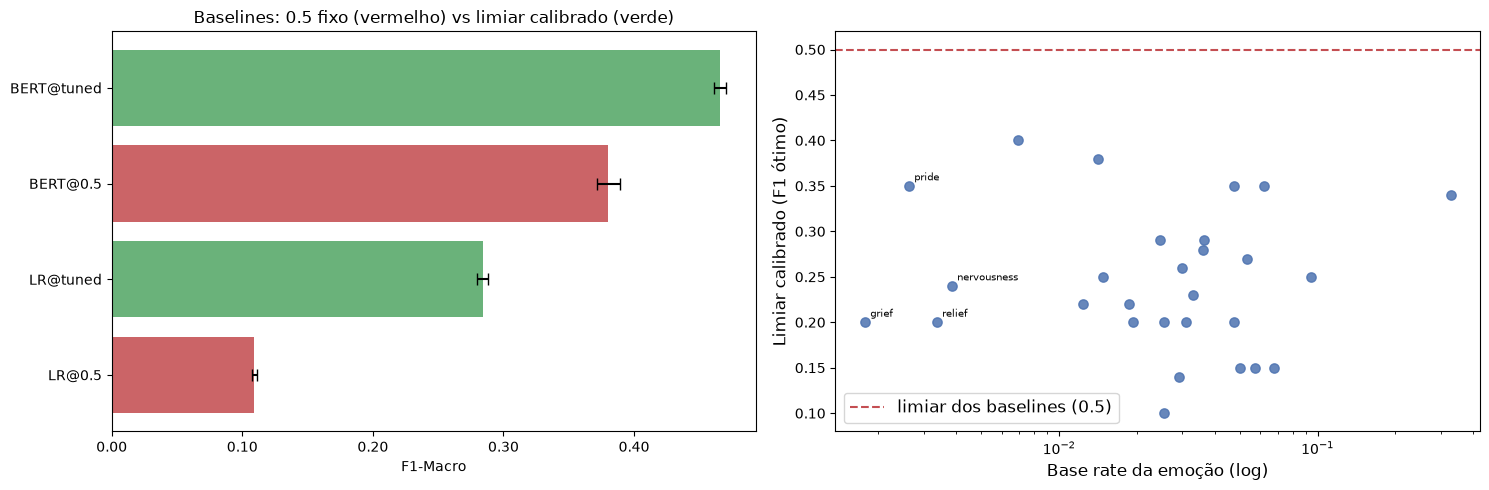

In [ ]:
thr_mean = pd.DataFrame(
    {f"fold_{k}": thr_store[k]["BERT"] for k in thr_store}, index=EMOTION_COLS
).mean(axis=1)

df_thr = pd.DataFrame({
    "limiar_calibrado": thr_mean,
    "base_rate": base_rates.reindex(EMOTION_COLS),
}).sort_values("base_rate")

print("===== LIMIAR CALIBRADO POR EMOÇÃO (BERTimbau, média entre folds) =====")
display(df_thr.round(4))
print(f"\nLimiar médio calibrado: {thr_mean.mean():.3f} (vs 0.5 nos baselines)")
print(f"Emoções com limiar ótimo < 0.5: {int((thr_mean < 0.5).sum())}/{N_LABELS}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
order = df_final.sort_values("f1_macro")
cols = ["#C44E52" if "@0.5" in i else "#55A868" for i in order.index]
ax.barh(order.index, order["f1_macro"], xerr=order["f1_macro_std"],
        capsize=4, color=cols, alpha=0.88)
ax.set_xlabel("F1-Macro")
ax.set_title("Baselines: 0.5 fixo (vermelho) vs limiar calibrado (verde)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax2 = axes[1]
ax2.scatter(df_thr["base_rate"], df_thr["limiar_calibrado"], s=45, color="#4C72B0", alpha=0.85)
ax2.axhline(0.5, color="#C44E52", linestyle="--", label="limiar dos baselines (0.5)")
ax2.set_xscale("log")
ax2.set_xlabel("Base rate da emoção (log)", fontsize=12)
ax2.set_ylabel("Limiar calibrado (F1 ótimo)", fontsize=12)
ax2.legend(fontsize=12)
for emo in df_thr.index[:4]:
    ax2.annotate(emo, (df_thr.loc[emo, "base_rate"], df_thr.loc[emo, "limiar_calibrado"]),
                 fontsize=7, xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.savefig(OUT_INTERP / "testes_limiar_bert.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_thresh.to_csv(OUT_INTERP / "efeito_limiar.csv")
df_final.to_csv(OUT_INTERP / "comparacao_baselines_limiar.csv")
df_thr.to_csv(OUT_INTERP / "limiares_calibrados_por_emocao.csv")
pd.DataFrame({name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
              for name, v in results.items()}).to_csv(OUT_INTERP / "f1_por_label_limiar.csv")
np.save(OUT_INTERP / "thresholds_bert.npy",
        np.vstack([thr_store[k]["BERT"] for k in sorted(thr_store)]))

summary = {
    "objetivo": ("Medir os baselines (BERTimbau, LR) com o MESMO tratamento de limiar que o "
                 "Ensemble Fuzzy recebe (calibrado por emocao, OOF), em vez de 0.5 fixo."),
    "protocolo": ("Para cada outer fold k: limiares calibrados por emocao nas probabilidades OOF "
                  "dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em P[k]. "
                  "Nenhum limiar escolhido no fold de teste."),
    "fontes": {"BERT": str(BERT_CACHE), "LR": f"{LR_CACHE} (variante {LR_VARIANT})"},
    "grade_justa": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "resultados": {name: {
        "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
        "precision_macro": f"{d['precision_macro'].mean():.4f}",
        "recall_macro": f"{d['recall_macro'].mean():.4f}",
        "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
    } for name, d in dfs.items()},
    "limiar_medio_bert": float(thr_mean.mean()),
    "n_emocoes_limiar_abaixo_0.5": int((thr_mean < 0.5).sum()),
}
with open(OUT_INTERP / "testes_limiar_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_INTERP.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy
{
  "objetivo": "Medir os baselines (BERTimbau, LR) com o MESMO tratamento de limiar que o Ensemble Fuzzy recebe (calibrado por emocao, OOF), em vez de 0.5 fixo.",
  "protocolo": "Para cada outer fold k: limiares calibrados por emocao nas probabilidades OOF dos folds j!=k (grade identica a THRESH_GRID do fuzzy), aplicados em P[k]. Nenhum limiar escolhido no fold de teste.",
  "fontes": {
    "BERT": "..\\data\\out\\bertimbau\\cache",
    "LR": "..\\data\\out\\baseline_LR\\cache (variante nosmote)"
  },
  "grade_justa": [
    0.05,
    0.95,
    19
  ],
  "resultados": {
    "BERT@0.5": {
      "f1_macro": "0.3804 +/- 0.0088",
      "precision_macro": "0.5861",
      "recall_macro": "0.3233",
      "avg_precision_macro": "0.4290"
    },
    "BERT@tuned": {
      "f1_macro": "0.4655 +/- 0.0046",
      "precision_macro": "0.4543",
      "recall_macro": "0.4884"

# PARTE 1 — Sistema de Inferência Nebulosa (SIN) para emoções

## Setup fuzzy e escolha das emoções-demo

In [ ]:
import itertools
import seaborn as sns
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

OUT_INTERP = Path("../data/out/ensemble_fuzzy_interpretacao")
OUT_INTERP.mkdir(parents=True, exist_ok=True)

FOLD_DEMO = 1   # fold usado para as demonstrações (regras vêm do outer-train dele)

# ── Pontos de decisão (τ) calibrados na Parte 0 ──────────────────
tau_bert = pd.DataFrame({f"f{k}": thr_store[k]["BERT"] for k in thr_store},
                        index=EMOTION_COLS).mean(axis=1)
tau_lr   = pd.DataFrame({f"f{k}": thr_store[k]["LR"]   for k in thr_store},
                        index=EMOTION_COLS).mean(axis=1)

# ── Emoções-demo: melhor e pior F1 (BERT calibrado) ──────────────
f1_lab = pd.DataFrame([m["f1_per_label"] for m in results["BERT@tuned"]]).mean()
EMO_BEST  = f1_lab.idxmax()
EMO_WORST = f1_lab.idxmin()

print("═" * 62)
print("EMOÇÕES SELECIONADAS PARA ANÁLISE APROFUNDADA")
print("═" * 62)
for rot, emo in [("MELHOR", EMO_BEST), ("PIOR", EMO_WORST)]:
    print(f"  {rot:6s}: {emo:15s} | F1={f1_lab[emo]:.4f} | "
          f"base_rate={base_rates[emo]:.4f} | "
          f"τ_BERT={tau_bert[emo]:.2f} | τ_LR={tau_lr[emo]:.2f}")

print("\nRanking completo (F1 por emoção):")
display(pd.DataFrame({
    "F1": f1_lab, "base_rate": base_rates.reindex(f1_lab.index),
    "τ_BERT": tau_bert.reindex(f1_lab.index), "τ_LR": tau_lr.reindex(f1_lab.index),
}).sort_values("F1", ascending=False).round(4))

══════════════════════════════════════════════════════════════
EMOÇÕES SELECIONADAS PARA ANÁLISE APROFUNDADA
══════════════════════════════════════════════════════════════
  MELHOR: gratitude       | F1=0.8969 | base_rate=0.0622 | τ_BERT=0.35 | τ_LR=0.27
  PIOR  : realization     | F1=0.1866 | base_rate=0.0255 | τ_BERT=0.10 | τ_LR=0.05

Ranking completo (F1 por emoção):


,F1,base_rate,τ_BERT,τ_LR
gratitude,0.8969,0.0622,0.35,0.27
love,0.7723,0.0475,0.35,0.26
amusement,0.7578,0.0533,0.27,0.15
remorse,0.6519,0.0123,0.22,0.05
neutral,0.6401,0.3273,0.34,0.30
admiration,0.6390,0.0944,0.25,0.33
fear,0.5665,0.0141,0.38,0.10
optimism,0.5434,0.0364,0.29,0.15
pride,0.5121,0.0026,0.35,0.05
surprise,0.5078,0.0245,0.29,0.05


## Variável de polaridade (contexto léxico)

A terceira entrada do SIN é a **polaridade** do texto, derivada das features de sentimento que já
existem no `data.parquet` (as mesmas que o `baseline_LR` usa: prefixos `sent_bert`, `leia`, `op_`).
Combinamos os sinais positivo e negativo em um único valor em `[0, 1]` — `0 = NEGATIVA`, `0.5 =
NEUTRA`, `1 = POSITIVA`. Se nenhuma coluna de sentimento estiver disponível, o notebook recorre a uma
polaridade de **concordância** entre os dois modelos (calculável só das probabilidades).

In [ ]:
# ── Polaridade a partir das features de sentimento do parquet ─────
# Procura colunas de sentimento positivo/negativo; combina em [0,1].
SENT_PREFIXES = ("sent_bert", "leia", "op_")

def _cols(df, prefixo):
    return [c for c in df.columns if c.startswith(prefixo) and pd.api.types.is_numeric_dtype(df[c])]

def _find_pos_neg(df):
    """Tenta identificar um par (positivo, negativo) entre as features de sentimento."""
    cand = [c for c in df.columns if c.startswith(SENT_PREFIXES)]
    pos = [c for c in cand if any(t in c.lower() for t in ("pos", "positiv", "_p"))]
    neg = [c for c in cand if any(t in c.lower() for t in ("neg", "negativ", "_n"))]
    return (pos[0] if pos else None), (neg[0] if neg else None), cand

df0 = folds_data[1]["df"]
col_pos, col_neg, cand_sent = _find_pos_neg(df0)

if col_pos is not None and col_neg is not None:
    def _pol(df):
        p = df[col_pos].fillna(0).to_numpy(dtype=float)
        n = df[col_neg].fillna(0).to_numpy(dtype=float)
        return np.clip(0.5 + 0.5 * (p - n), 0.0, 1.0)
    POL_folds = {k: _pol(folds_data[k]["df"]) for k in folds_data}
    print(f"Polaridade a partir do léxico: pos='{col_pos}', neg='{col_neg}'.")

elif cand_sent:
    # há sentimento, mas sem par pos/neg claro: usa a 1ª coluna, reescalada para [0,1]
    c = cand_sent[0]
    allv = np.concatenate([folds_data[k]["df"][c].fillna(0).to_numpy(dtype=float) for k in folds_data])
    lo, hi = np.percentile(allv, 2), np.percentile(allv, 98)
    def _pol1(df):
        v = df[c].fillna(0).to_numpy(dtype=float)
        return np.clip((v - lo) / max(hi - lo, 1e-6), 0.0, 1.0)
    POL_folds = {k: _pol1(folds_data[k]["df"]) for k in folds_data}
    print(f"Polaridade a partir de uma única feature de sentimento: '{c}' (reescalada 2–98%).")

else:
    # fallback sem léxico: concordância entre os modelos (só das probabilidades)
    # alto quando LR e BERT concordam; some por emoção -> valor por texto
    POL_folds = {k: 1.0 - np.abs(P_LR_folds[k] - P_BERT_folds[k]).mean(axis=1) for k in folds_data}
    print("Sem features de sentimento no parquet — usando 'concordância' entre LR e BERT.")

pol_all = np.concatenate([POL_folds[k] for k in folds_data])
print(f"Polaridade — média={pol_all.mean():.3f} | "
      f"% neutra (0.45–0.55)={100*np.mean((pol_all>=0.45)&(pol_all<=0.55)):.1f}%")

Polaridade a partir do léxico: pos='sent_bert_pos', neg='sent_bert_neg'.
Polaridade — média=0.487 | % neutra (0.45–0.55)=30.6%


## Variáveis linguísticas ancoradas em τ

In [ ]:
# ══════════════════════════════════════════════════════════════════
# VARIÁVEIS LINGUÍSTICAS
#
# Decisão de projeto central: os termos de p_lr e p_bert são ancorados no
# ponto de decisão τ calibrado para CADA emoção, e não em quantis dos dados.
#
#   BAIXA : evidência abaixo do ponto de decisão
#   MEDIA : evidência na vizinhança do ponto de decisão (zona de dúvida)
#   ALTA  : evidência acima do ponto de decisão
#
# Consequência: o rótulo linguístico é SEMANTICAMENTE VERDADEIRO. Uma partição
# por quantis produziria "ALTA" para p=0.05 em emoções raras — rótulo que mente.
#
# Extremos são TRAPÉZIOS (ombros): μ satura em 1 e permanece. Gaussianas nos
# extremos seriam NÃO-MONÓTONAS (μ cairia para p→1), penalizando justamente as
# predições mais confiantes.
# ══════════════════════════════════════════════════════════════════
U_P    = np.arange(0.0, 1.001, 0.001)   # universo das probabilidades
U_POL  = np.arange(0.0, 1.001, 0.001)   # universo da polaridade
U_PERT = np.arange(0.0, 1.001, 0.001)   # universo da pertinência (saída)

TERMOS_P    = ['BAIXA', 'MEDIA', 'ALTA']
TERMOS_POL  = ['NEGATIVA', 'NEUTRA', 'POSITIVA']
TERMOS_PERT = ['MUITO_BAIXA', 'BAIXA', 'MEDIA', 'ALTA', 'MUITO_ALTA']

def build_prob_antecedent(nome, tau):
    """Antecedente de probabilidade com termos ancorados no ponto de decisão τ."""
    tau = float(np.clip(tau, 0.06, 0.90))
    a = 0.5 * tau                    # início da zona de dúvida
    b = min(1.0, 2.0 * tau)          # fim da zona de dúvida
    var = ctrl.Antecedent(U_P, nome)
    var['BAIXA'] = fuzzy.trapmf(U_P, [0.0, 0.0, a, tau])       # ombro inferior
    var['MEDIA'] = fuzzy.trimf( U_P, [a, tau, b])
    var['ALTA']  = fuzzy.trapmf(U_P, [tau, b, 1.0, 1.0])       # ombro superior
    return var

def build_polaridade():
    var = ctrl.Antecedent(U_POL, 'polaridade')
    var['NEGATIVA'] = fuzzy.trapmf(U_POL, [0.00, 0.00, 0.30, 0.45])
    var['NEUTRA']   = fuzzy.trimf( U_POL, [0.35, 0.50, 0.65])
    var['POSITIVA'] = fuzzy.trapmf(U_POL, [0.55, 0.70, 1.00, 1.00])
    return var

def build_pertinencia():
    """Saída com 5 termos — resolução suficiente sem sacrificar legibilidade."""
    var = ctrl.Consequent(U_PERT, 'pertinencia')
    var['MUITO_BAIXA'] = fuzzy.trapmf(U_PERT, [0.00, 0.00, 0.10, 0.25])
    var['BAIXA']       = fuzzy.trimf( U_PERT, [0.10, 0.28, 0.45])
    var['MEDIA']       = fuzzy.trimf( U_PERT, [0.35, 0.50, 0.65])
    var['ALTA']        = fuzzy.trimf( U_PERT, [0.55, 0.72, 0.90])
    var['MUITO_ALTA']  = fuzzy.trapmf(U_PERT, [0.75, 0.90, 1.00, 1.00])
    return var

def mu(universo, mf, valores):
    """Pertinência vetorizada (rápida, para os 43k pontos de calibração)."""
    return np.interp(np.asarray(valores, dtype=float), universo, mf)

print("Construtores de variáveis linguísticas prontos.")

Construtores de variáveis linguísticas prontos.


## Gráficos das variáveis (o "retrato" do sistema)

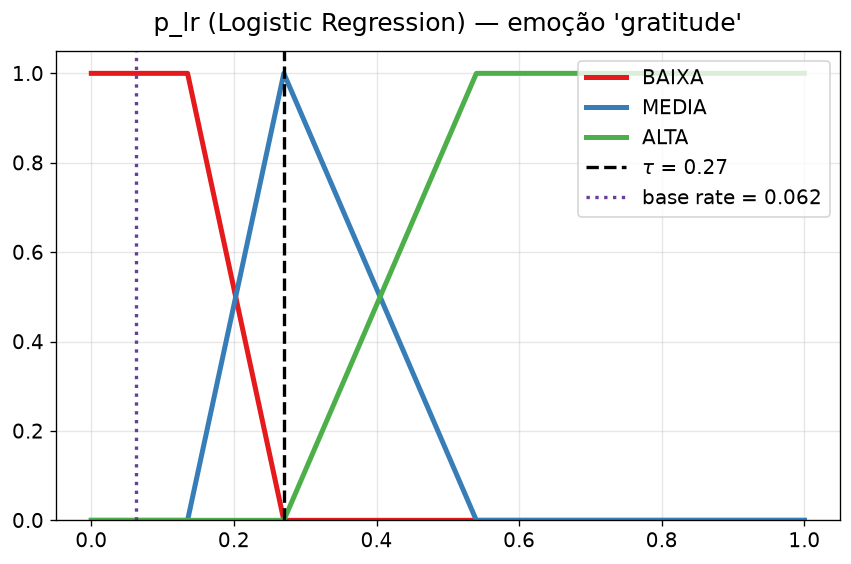

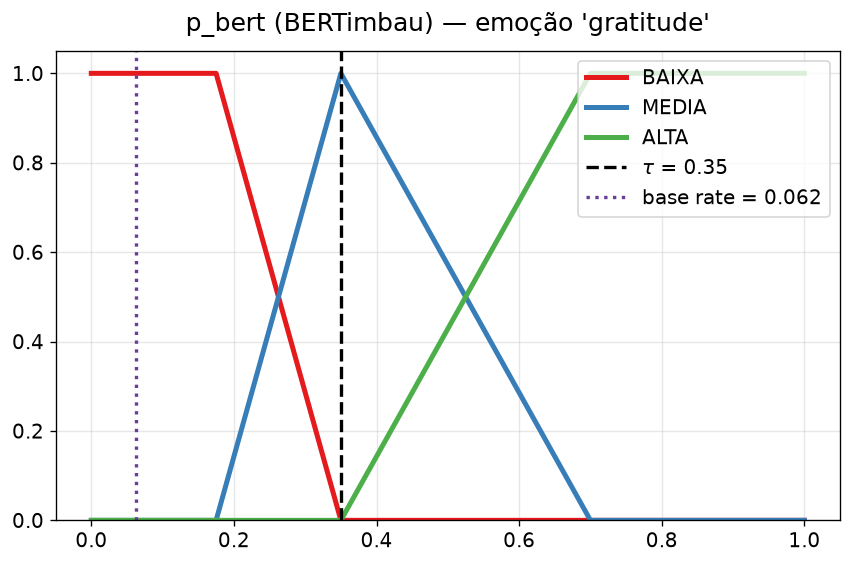

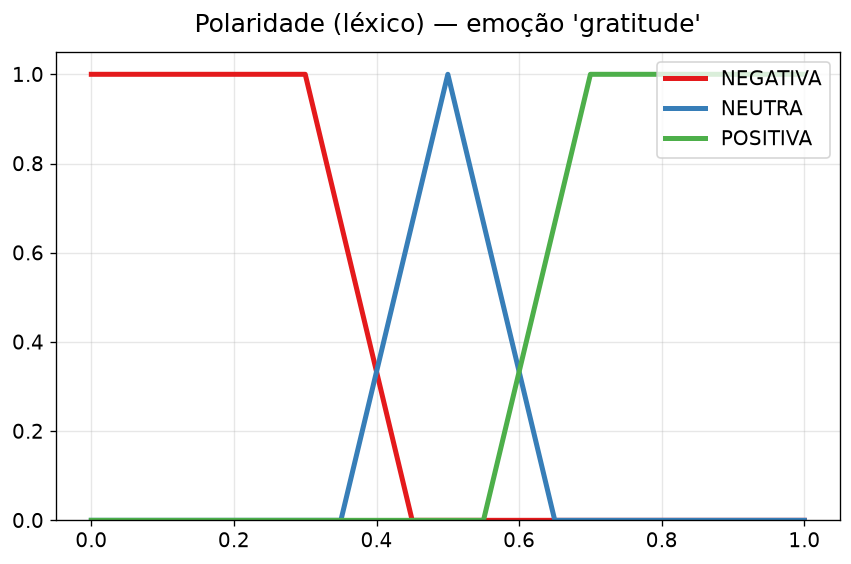

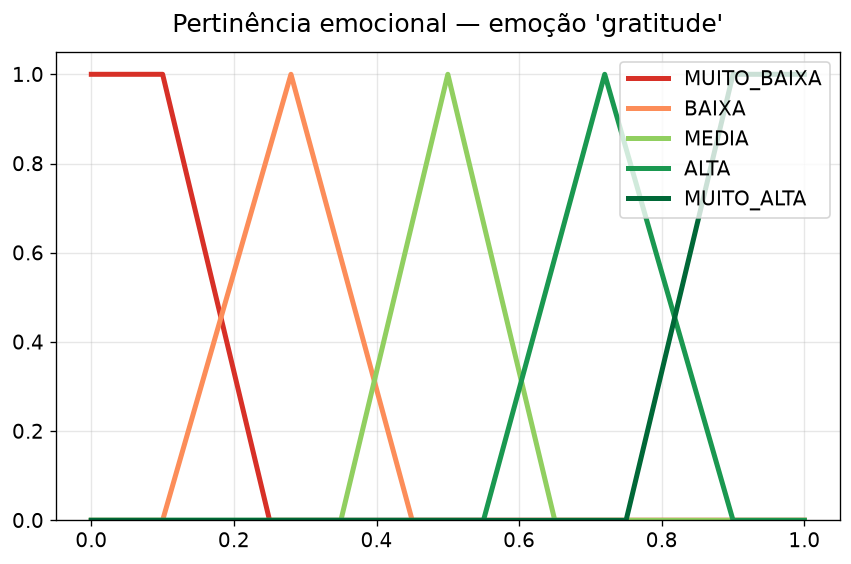

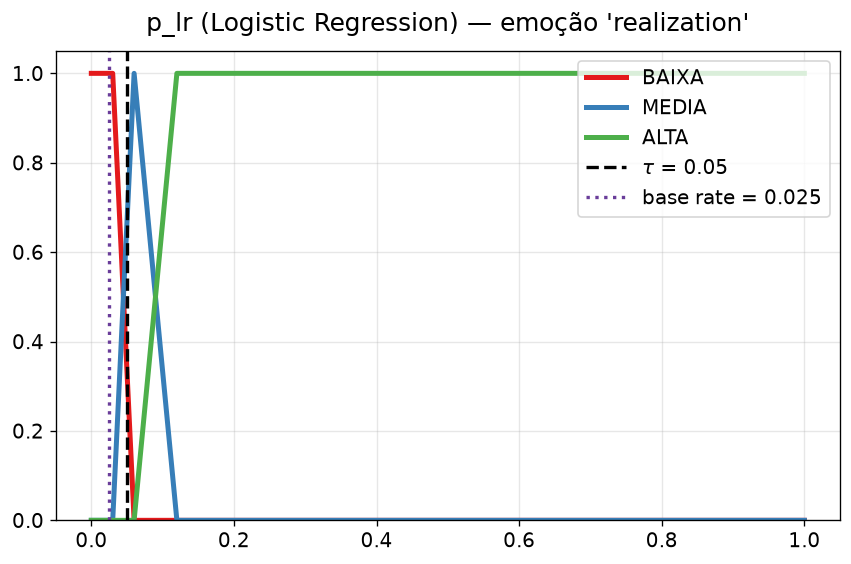

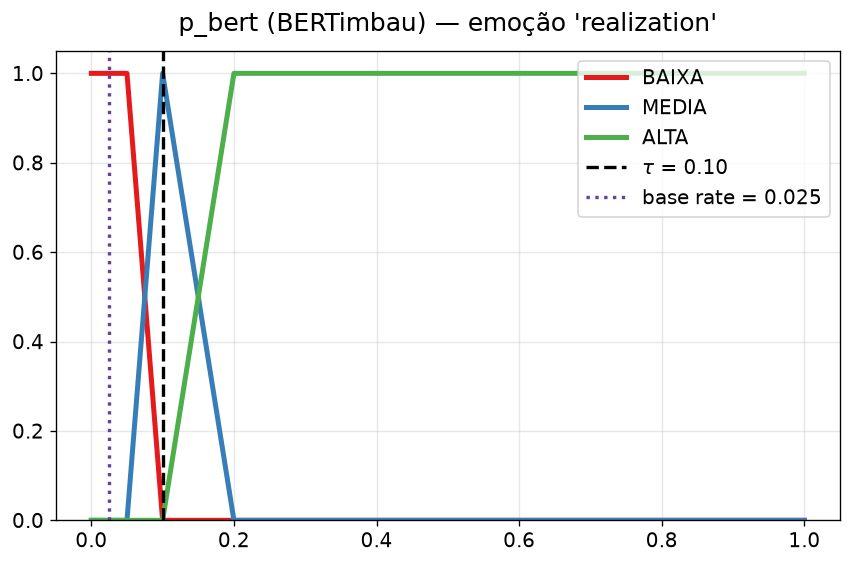

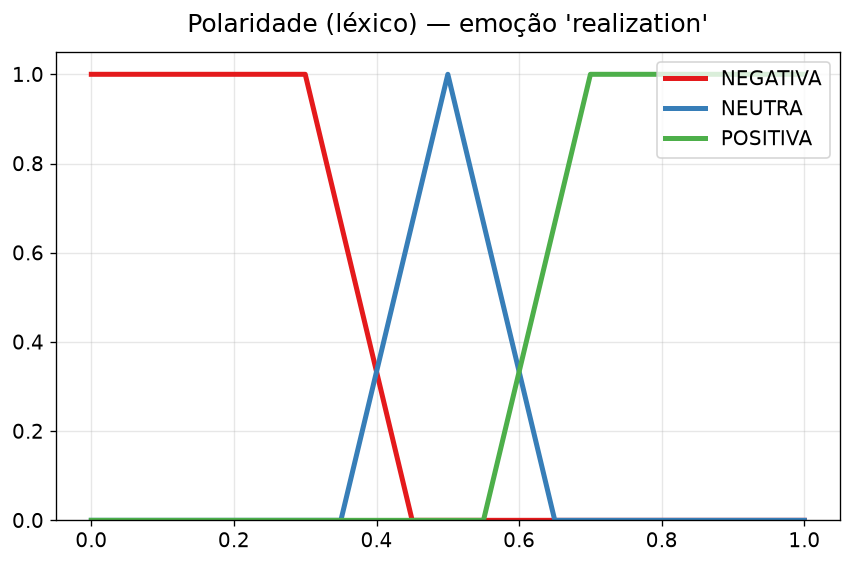

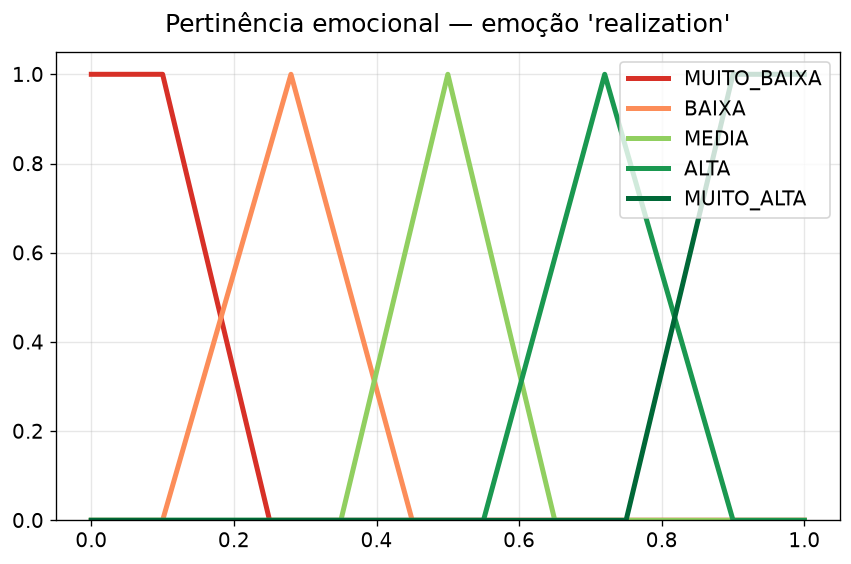

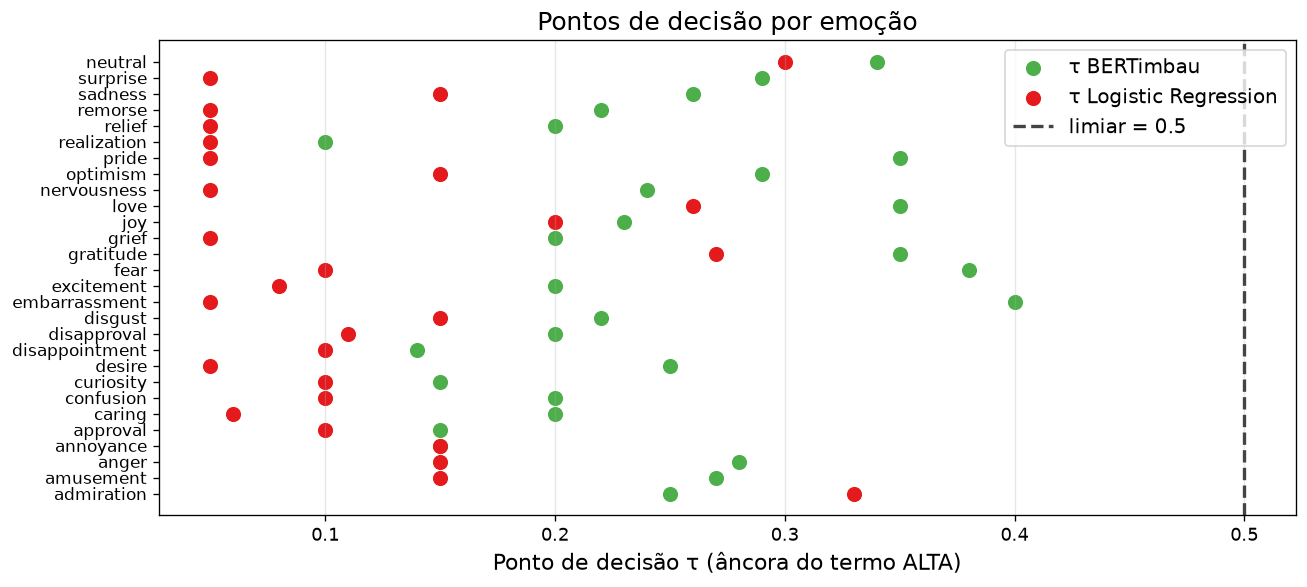

τ médio BERTimbau: 0.245 | τ médio LR: 0.124
Leitura: o LR exige evidência MAIS ALTA para a mesma decisão — efeito do SMOTE, que reequilibra o treino e infla as probabilidades. O BERTimbau, treinado com CB-Loss sobre a distribuição real, decide bem abaixo de 0.5.


In [ ]:
# ============================================================
# Paletas de cores
# ============================================================

# Variáveis linguísticas (ColorBrewer Set1)
# Alto contraste e sem amarelo apagado.
PALETA_VARIAVEIS = [
    "#E41A1C",  # vermelho
    "#377EB8",  # azul
    "#4DAF4A",  # verde
    "#984EA3",  # roxo
    "#FF7F00",  # laranja
]

# Pertinência (mantive a que ficou boa)
PALETA_PERT = [
    "#D73027",
    "#FC8D59",
    "#91CF60",
    "#1A9850",
    "#006837",
]

# ============================================================
# Gráficos das variáveis linguísticas
# ============================================================

def plot_variaveis_emocao(emo):

    v_lr = build_prob_antecedent("p_lr", tau_lr[emo])
    v_bert = build_prob_antecedent("p_bert", tau_bert[emo])
    v_pol = build_polaridade()
    v_pert = build_pertinencia()

    graficos = [
        (
            v_lr,
            U_P,
            TERMOS_P,
            "p_lr (Logistic Regression)",
            tau_lr[emo],
            "variavel_lr",
        ),
        (
            v_bert,
            U_P,
            TERMOS_P,
            "p_bert (BERTimbau)",
            tau_bert[emo],
            "variavel_bert",
        ),
        (
            v_pol,
            U_POL,
            TERMOS_POL,
            "Polaridade (léxico)",
            None,
            "variavel_polaridade",
        ),
    ]

    # ========================================================
    # Um gráfico para cada variável linguística
    # ========================================================

    for var, universo, termos, titulo, tau, nome in graficos:

        fig, ax = plt.subplots(figsize=(7.2, 4.8))

        cores = PALETA_VARIAVEIS[: len(termos)]

        for termo, cor in zip(termos, cores):
            ax.plot(
                universo,
                var[termo].mf,
                color=cor,
                linewidth=3,
                label=termo,
            )

        if tau is not None:

            ax.axvline(
                tau,
                color="black",
                linestyle="--",
                linewidth=2,
                label=fr"$\tau$ = {tau:.2f}",
            )

            ax.axvline(
                base_rates[emo],
                color="#6A3D9A",
                linestyle=":",
                linewidth=2,
                label=f"base rate = {base_rates[emo]:.3f}",
            )

        ax.set_title(
            f"{titulo} — emoção '{emo}'",
            fontsize=15,
            pad=12,
        )

        ax.set_ylim(0, 1.05)

        ax.grid(alpha=0.30)

        ax.tick_params(labelsize=12)

        ax.legend(
            fontsize=12,
            frameon=True,
            loc="upper right",
        )

        plt.tight_layout()

        plt.savefig(
            OUT_INTERP / f"{nome}_{emo}.png",
            dpi=180,
            bbox_inches="tight",
        )

        plt.show()

    # ========================================================
    # Pertinência (mantida separada)
    # ========================================================

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    cores = PALETA_PERT[: len(TERMOS_PERT)]

    for termo, cor in zip(TERMOS_PERT, cores):
        ax.plot(
            U_PERT,
            v_pert[termo].mf,
            color=cor,
            linewidth=3,
            label=termo,
        )

    ax.set_title(
        f"Pertinência emocional — emoção '{emo}'",
        fontsize=15,
        pad=12,
    )

    ax.set_ylim(0, 1.05)

    ax.grid(alpha=0.30)

    ax.tick_params(labelsize=12)

    ax.legend(
        fontsize=12,
        frameon=True,
        loc="upper right",
    )

    plt.tight_layout()

    plt.savefig(
        OUT_INTERP / f"pertinencia_{emo}.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()


# ============================================================
# Melhor e pior emoção
# ============================================================

for emo in [EMO_BEST, EMO_WORST]:
    plot_variaveis_emocao(emo)


# ============================================================
# Comparação dos τ
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))

ax.scatter(
    tau_bert.values,
    np.arange(N_LABELS),
    color="#4DAF4A",
    s=65,
    label="τ BERTimbau",
)

ax.scatter(
    tau_lr.values,
    np.arange(N_LABELS),
    color="#E41A1C",
    s=65,
    label="τ Logistic Regression",
)

ax.axvline(
    0.5,
    color="#444444",
    linestyle="--",
    linewidth=2,
    label="limiar = 0.5",
)

ax.set_title(
    "Pontos de decisão por emoção",
    fontsize=15,
)

ax.set_xlabel(
    "Ponto de decisão τ (âncora do termo ALTA)",
    fontsize=13,
)

ax.set_yticks(np.arange(N_LABELS))
ax.set_yticklabels(
    EMOTION_COLS,
    fontsize=10,
)

ax.tick_params(axis="x", labelsize=11)

ax.grid(
    axis="x",
    alpha=0.30,
)

ax.legend(
    fontsize=12,
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    OUT_INTERP / "taus_por_emocao.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"τ médio BERTimbau: {tau_bert.mean():.3f} | "
    f"τ médio LR: {tau_lr.mean():.3f}"
)

print(
    "Leitura: o LR exige evidência MAIS ALTA para a mesma decisão — efeito do "
    "SMOTE, que reequilibra o treino e infla as probabilidades. "
    "O BERTimbau, treinado com CB-Loss sobre a distribuição real, "
    "decide bem abaixo de 0.5."
)

## MAF: método do especialista (conhecimento de domínio)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# MÉTODO 1 — MAF do ESPECIALISTA (conhecimento de domínio, sem dados)
#
# Heurísticas codificadas:
#   ↑ p_bert  →  ↑ pertinência  (peso DOBRO: é o modelo mais preciso)
#   ↑ p_lr    →  ↑ pertinência  (peso simples: alto recall, baixa precisão)
#   polaridade CONCORDA com a valência da emoção  →  reforça
#   polaridade DISCORDA da valência               →  atenua
# ══════════════════════════════════════════════════════════════════
VALENCIA = {
    'admiration': +1, 'amusement': +1, 'approval': +1, 'caring': +1, 'desire': +1,
    'excitement': +1, 'gratitude': +1, 'joy': +1, 'love': +1, 'optimism': +1,
    'pride': +1, 'relief': +1,
    'anger': -1, 'annoyance': -1, 'disappointment': -1, 'disapproval': -1,
    'disgust': -1, 'embarrassment': -1, 'fear': -1, 'grief': -1,
    'nervousness': -1, 'remorse': -1, 'sadness': -1,
    'confusion': 0, 'curiosity': 0, 'realization': 0, 'surprise': 0, 'neutral': 0,
}

def maf_especialista(i_lr, i_bert, i_pol, emo):
    """Índices 0/1/2 (BAIXA/MEDIA/ALTA) → índice 0..4 do termo de saída."""
    bruto = i_lr + 2 * i_bert                 # 0..6  (BERT pesa o dobro)
    idx = bruto * 4.0 / 6.0                   # reescala p/ 0..4
    val = VALENCIA.get(emo, 0)
    if val != 0:
        sinal_pol = i_pol - 1                 # -1 NEG | 0 NEU | +1 POS
        idx += 0.5 * sinal_pol * val          # concorda reforça, discorda atenua
    return int(np.clip(round(idx), 0, 4))


def gerar_maf_especialista(emo):
    linhas = []
    for i_lr, i_bert, i_pol in itertools.product(range(3), range(3), range(3)):
        linhas.append({
            't_lr': TERMOS_P[i_lr], 't_bert': TERMOS_P[i_bert], 't_pol': TERMOS_POL[i_pol],
            't_pert': TERMOS_PERT[maf_especialista(i_lr, i_bert, i_pol, emo)],
            'origem': 'especialista', 'suporte': np.nan, 'conf': np.nan,
        })
    return pd.DataFrame(linhas)

df_esp_best = gerar_maf_especialista(EMO_BEST)
print(f"Regras do especialista para '{EMO_BEST}': {len(df_esp_best)} (3×3×3 = cobertura total)")
display(df_esp_best.head(9))

Regras do especialista para 'gratitude': 27 (3×3×3 = cobertura total)


,t_lr,t_bert,t_pol,t_pert,origem,suporte,conf
0,BAIXA,BAIXA,NEGATIVA,MUITO_BAIXA,especialista,NaN,NaN
1,BAIXA,BAIXA,NEUTRA,MUITO_BAIXA,especialista,NaN,NaN
2,BAIXA,BAIXA,POSITIVA,MUITO_BAIXA,especialista,NaN,NaN
3,BAIXA,MEDIA,NEGATIVA,BAIXA,especialista,NaN,NaN
4,BAIXA,MEDIA,NEUTRA,BAIXA,especialista,NaN,NaN
5,BAIXA,MEDIA,POSITIVA,MEDIA,especialista,NaN,NaN
6,BAIXA,ALTA,NEGATIVA,MEDIA,especialista,NaN,NaN
7,BAIXA,ALTA,NEUTRA,ALTA,especialista,NaN,NaN
8,BAIXA,ALTA,POSITIVA,ALTA,especialista,NaN,NaN


## MAF: método Wang–Mendel (extraída dos dados)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# MÉTODO 2 — WANG–MENDEL (regras extraídas dos dados OOF)
#
# Cada amostra vota na célula (t_lr, t_bert, t_pol) do seu termo dominante,
# com peso = grau de disparo. O consequente da célula sai da razão entre
# massa positiva e negativa. Células sem dados são preenchidas pelo especialista
# (híbrido dados + conhecimento — como no trabalho de referência).
# ══════════════════════════════════════════════════════════════════
def fuzzificar_bulk(emo, p_lr_vals, p_bert_vals, pol_vals):
    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()
    M_lr   = np.column_stack([mu(U_P,   v_lr[t].mf,   p_lr_vals)   for t in TERMOS_P])
    M_bert = np.column_stack([mu(U_P,   v_bert[t].mf, p_bert_vals) for t in TERMOS_P])
    M_pol  = np.column_stack([mu(U_POL, v_pol[t].mf,  pol_vals)    for t in TERMOS_POL])
    return M_lr, M_bert, M_pol


def wang_mendel(emo, fold_demo=FOLD_DEMO, media_ratio=1.15):
    """Extrai a MAF dos dados do outer-train do fold_demo."""
    ks = [k for k in folds_data if k != fold_demo]
    p_lr   = np.vstack([P_LR_folds[k]   for k in ks])[:, EMOTION_COLS.index(emo)]
    p_bert = np.vstack([P_BERT_folds[k] for k in ks])[:, EMOTION_COLS.index(emo)]
    pol    = np.concatenate([POL_folds[k] for k in ks])
    y      = np.vstack([Y_folds[k] for k in ks])[:, EMOTION_COLS.index(emo)]

    M_lr, M_bert, M_pol = fuzzificar_bulk(emo, p_lr, p_bert, pol)
    i_lr, i_bert, i_pol = M_lr.argmax(1), M_bert.argmax(1), M_pol.argmax(1)
    grau = M_lr.max(1) * M_bert.max(1) * M_pol.max(1)      # t-norma produto

    # peso suave p/ a classe positiva (o τ já faz o balanceamento grosso)
    pw = float(np.clip(np.sqrt((1 - base_rates[emo]) / max(base_rates[emo], 1e-6)), 1.0, 4.0))
    w = grau * np.where(y == 1, pw, 1.0)

    codigo = i_lr * 9 + i_bert * 3 + i_pol
    linhas = []
    for cod in range(27):
        m = codigo == cod
        a, b, c = cod // 9, (cod % 9) // 3, cod % 3
        s_pos, s_neg = w[m & (y == 1)].sum(), w[m & (y == 0)].sum()
        tot, n_cru = s_pos + s_neg, int(m.sum())

        if tot <= 0 or n_cru < 10:                       # célula vazia/rala
            t_pert = TERMOS_PERT[maf_especialista(a, b, c, emo)]
            origem, conf = 'especialista (célula sem dados)', np.nan
        else:
            r = s_pos / tot
            if   r > 0.70: idx = 4
            elif r > 0.55: idx = 3
            elif r > 0.40: idx = 2
            elif r > 0.20: idx = 1
            else:          idx = 0
            t_pert, origem, conf = TERMOS_PERT[idx], 'dados', r

        linhas.append({'t_lr': TERMOS_P[a], 't_bert': TERMOS_P[b], 't_pol': TERMOS_POL[c],
                       't_pert': t_pert, 'origem': origem,
                       'suporte': round(tot, 1), 'n_amostras': n_cru,
                       'conf': None if conf != conf else round(conf, 3)})
    return pd.DataFrame(linhas)


df_wm_best  = wang_mendel(EMO_BEST)
df_wm_worst = wang_mendel(EMO_WORST)

for emo, df in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    n_dados = (df['origem'] == 'dados').sum()
    print(f"\n'{emo}': {n_dados}/27 células com suporte de dados, "
          f"{27-n_dados}/27 preenchidas pelo especialista")
    print(f"  Distribuição dos consequentes: {df['t_pert'].value_counts().to_dict()}")

print(f"\n── Base de regras Wang–Mendel para '{EMO_BEST}' (top 10 por suporte) ──")
display(df_wm_best.sort_values('suporte', ascending=False).head(10))


'gratitude': 23/27 células com suporte de dados, 4/27 preenchidas pelo especialista
  Distribuição dos consequentes: {'MUITO_ALTA': 13, 'MUITO_BAIXA': 6, 'MEDIA': 4, 'ALTA': 3, 'BAIXA': 1}

'realization': 21/27 células com suporte de dados, 6/27 preenchidas pelo especialista
  Distribuição dos consequentes: {'MUITO_BAIXA': 7, 'BAIXA': 6, 'ALTA': 6, 'MEDIA': 4, 'MUITO_ALTA': 4}

── Base de regras Wang–Mendel para 'gratitude' (top 10 por suporte) ──


,t_lr,t_bert,t_pol,t_pert,origem,suporte,n_amostras,conf
1,BAIXA,BAIXA,NEUTRA,MUITO_BAIXA,dados,13566.0,17246,0.017
0,BAIXA,BAIXA,NEGATIVA,MUITO_BAIXA,dados,12447.7,13499,0.012
2,BAIXA,BAIXA,POSITIVA,MUITO_BAIXA,dados,9222.6,9529,0.068
26,ALTA,ALTA,POSITIVA,MUITO_ALTA,dados,4323.0,1232,0.996
25,ALTA,ALTA,NEUTRA,MUITO_ALTA,dados,959.0,383,0.995
7,BAIXA,ALTA,NEUTRA,MUITO_ALTA,dados,349.7,159,0.939
17,MEDIA,ALTA,POSITIVA,MUITO_ALTA,dados,324.6,135,0.966
11,MEDIA,BAIXA,POSITIVA,MUITO_BAIXA,dados,317.4,390,0.180
24,ALTA,ALTA,NEGATIVA,MUITO_ALTA,dados,312.0,101,0.985
8,BAIXA,ALTA,POSITIVA,MUITO_ALTA,dados,310.0,127,0.915


## Heatmaps das MAFs (melhor vs pior emoção, especialista vs dados)

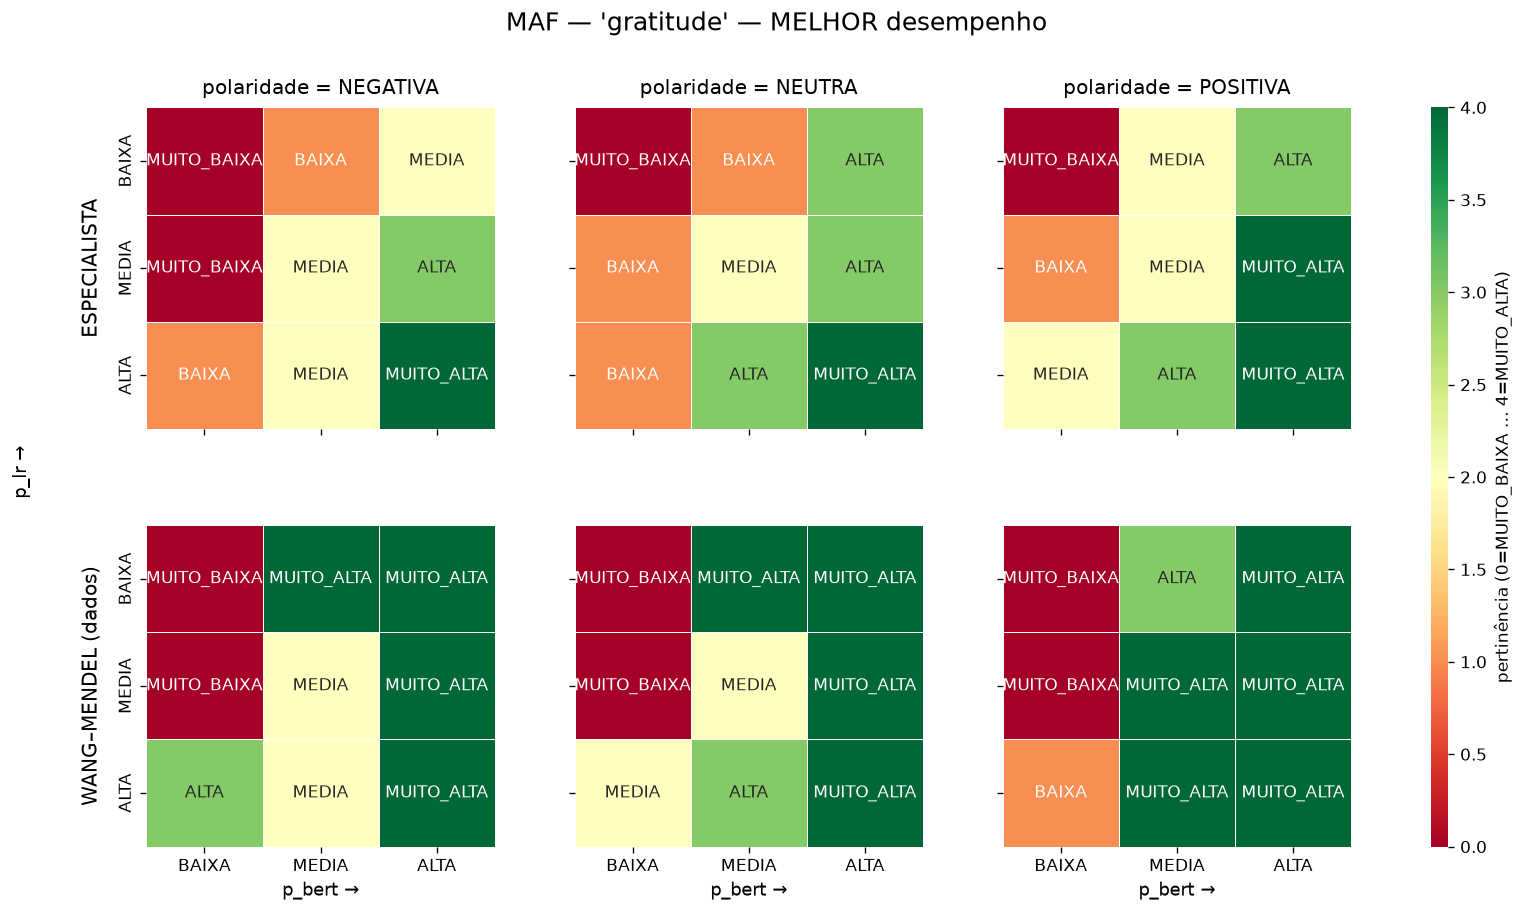

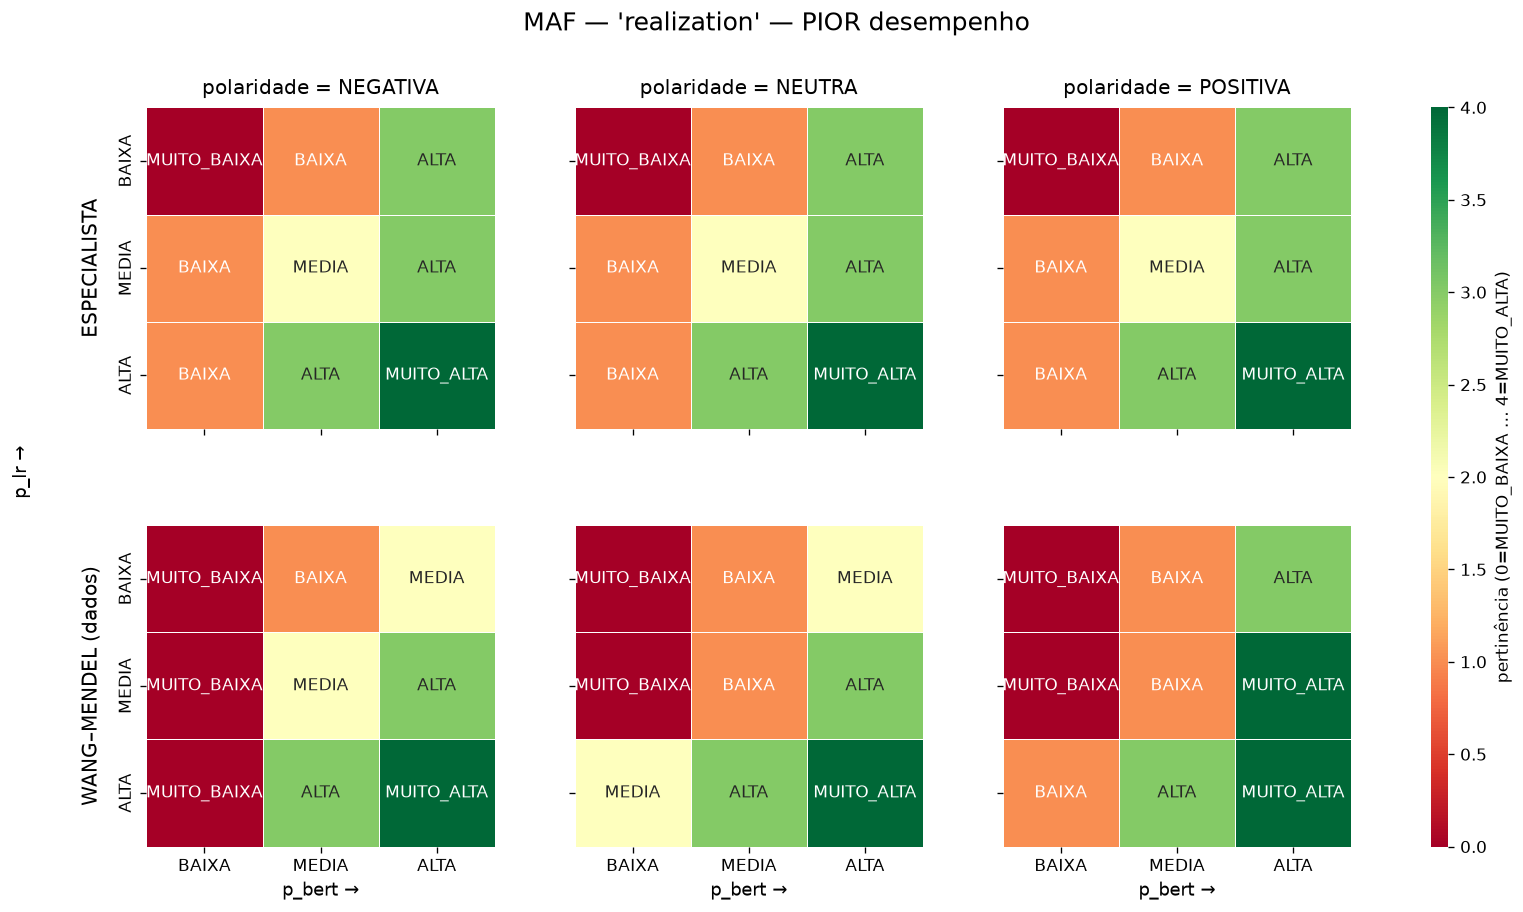

══════════════════════════════════════════════════════════════
CONCORDÂNCIA ESPECIALISTA × DADOS
══════════════════════════════════════════════════════════════
  gratitude      : 12/27 células idênticas | distância média = 0.81 termos
  realization    : 17/27 células idênticas | distância média = 0.37 termos


In [ ]:
ESCALA_PERT = {t: i for i, t in enumerate(TERMOS_PERT)}

def maf_para_df(df_reg, t_pol):
    """Tabela p_lr (linhas) × p_bert (colunas) para um termo de polaridade."""
    out = pd.DataFrame(index=TERMOS_P, columns=TERMOS_P, dtype=object)
    for t_lr in TERMOS_P:
        for t_bert in TERMOS_P:
            m = df_reg[
                (df_reg['t_lr'] == t_lr) &
                (df_reg['t_bert'] == t_bert) &
                (df_reg['t_pol'] == t_pol)
            ]
            out.loc[t_lr, t_bert] = m['t_pert'].values[0] if len(m) else '?'
    return out


def plot_mafs(emo, df_dados, titulo_extra=""):
    df_esp = gerar_maf_especialista(emo)

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.05],
                          wspace=0.30, hspace=0.30)
    axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(2)])
    cax = fig.add_subplot(gs[:, 3])

    fig.suptitle(f"MAF — '{emo}' {titulo_extra}", fontsize=15, y=0.98)

    for col, t_pol in enumerate(TERMOS_POL):
        for row, (df_reg, metodo) in enumerate([(df_esp, 'ESPECIALISTA'),
                                                (df_dados, 'WANG–MENDEL (dados)')]):
            ax = axes[row, col]
            tab = maf_para_df(df_reg, t_pol)
            num = tab.replace(ESCALA_PERT).apply(pd.to_numeric, errors='coerce')
            primeiro = (row == 0 and col == 2)

            sns.heatmap(num, annot=tab.values, fmt='', cmap='RdYlGn',
                        vmin=0, vmax=4, linewidths=0.6, ax=ax,
                        cbar=primeiro, cbar_ax=cax if primeiro else None,
                        annot_kws={"fontsize": 10})

            # coluna → polaridade (só no topo)
            if row == 0:
                ax.set_title(f"polaridade = {t_pol}", fontsize=12, pad=8)
            # linha → método (só à esquerda)
            ax.set_ylabel(metodo if col == 0 else "", fontsize=12, labelpad=10)
            # eixos só nas bordas
            ax.set_xlabel("p_bert →" if row == 1 else "", fontsize=11)
            if col > 0:
                ax.set_yticklabels([])
            if row == 0:
                ax.set_xticklabels([])
            ax.tick_params(axis="both", labelsize=10)

    # rótulo do eixo p_lr, uma vez só
    fig.text(0.045, 0.5, "p_lr →", rotation=90, va='center', fontsize=11)
    cax.set_ylabel("pertinência (0=MUITO_BAIXA … 4=MUITO_ALTA)", fontsize=10)

    plt.savefig(OUT_INTERP / f"maf_{emo}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_mafs(EMO_BEST, df_wm_best, "— MELHOR desempenho")
plot_mafs(EMO_WORST, df_wm_worst, "— PIOR desempenho")


# ── Concordância entre as duas MAFs ──────────────────────────────
print("═" * 62)
print("CONCORDÂNCIA ESPECIALISTA × DADOS")
print("═" * 62)

for emo, df_d in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    df_e = gerar_maf_especialista(emo)
    chave = ['t_lr', 't_bert', 't_pol']
    j = df_e.merge(df_d, on=chave, suffixes=('_esp', '_dados'))

    iguais = (j['t_pert_esp'] == j['t_pert_dados']).sum()
    dist = (
        j['t_pert_esp'].map(ESCALA_PERT)
        - j['t_pert_dados'].map(ESCALA_PERT)
    ).abs().mean()

    print(
        f"  {emo:15s}: {iguais}/27 células idênticas | "
        f"distância média = {dist:.2f} termos"
    )

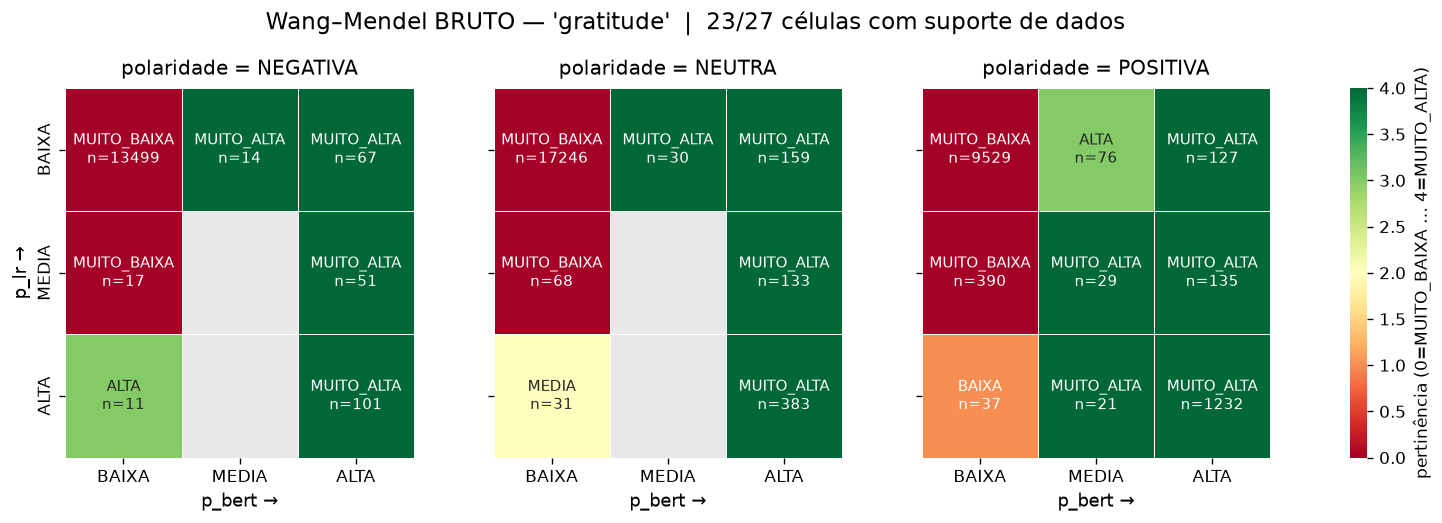

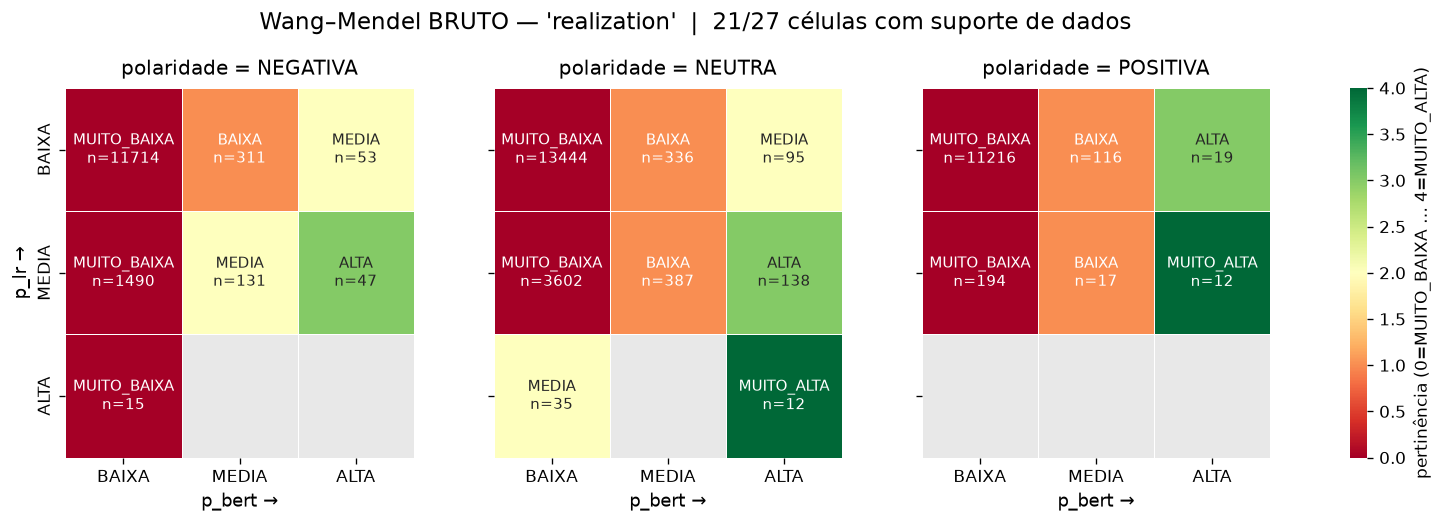

In [ ]:
def _pivot(df_reg, t_pol, coluna):
    out = pd.DataFrame(index=TERMOS_P, columns=TERMOS_P, dtype=object)
    for t_lr in TERMOS_P:
        for t_bert in TERMOS_P:
            m = df_reg[(df_reg['t_lr'] == t_lr) & (df_reg['t_bert'] == t_bert)
                       & (df_reg['t_pol'] == t_pol)]
            out.loc[t_lr, t_bert] = m[coluna].values[0] if len(m) else None
    return out


def plot_maf_bruta(emo, df_dados):
    """WM ANTES do preenchimento: buracos visíveis + nº de mensagens por célula."""
    fig = plt.figure(figsize=(14, 4))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.30)
    axes = [fig.add_subplot(gs[0, c]) for c in range(3)]
    cax = fig.add_subplot(gs[0, 3])

    n_dados = (df_dados['origem'] == 'dados').sum()
    fig.suptitle(f"Wang–Mendel BRUTO — '{emo}'  |  "
                 f"{n_dados}/27 células com suporte de dados",
                 fontsize=14, y=1.04)

    for col, t_pol in enumerate(TERMOS_POL):
        ax = axes[col]
        t_pert = _pivot(df_dados, t_pol, 't_pert')
        origem = _pivot(df_dados, t_pol, 'origem')
        n_amo  = _pivot(df_dados, t_pol, 'n_amostras')

        tem_dados = origem.map(lambda o: o == 'dados')
        num = t_pert.replace(ESCALA_PERT).apply(pd.to_numeric, errors='coerce')
        num = num.where(tem_dados)                      # buraco → NaN → cinza

        rot = pd.DataFrame(
            [[f"{t_pert.iloc[i, j]}\nn={n_amo.iloc[i, j]}" if tem_dados.iloc[i, j]
              else f"—\nn={n_amo.iloc[i, j]}"
              for j in range(3)] for i in range(3)],
            index=TERMOS_P, columns=TERMOS_P)

        primeiro = (col == 2)
        sns.heatmap(num, annot=rot.values, fmt='', cmap='RdYlGn',
                    vmin=0, vmax=4, linewidths=0.6, linecolor='white', ax=ax,
                    cbar=primeiro, cbar_ax=cax if primeiro else None,
                    annot_kws={"fontsize": 9},
                    mask=~tem_dados.values.astype(bool))  # célula vazia = branca

        ax.set_facecolor('#e8e8e8')                       # buraco em cinza
        ax.set_title(f"polaridade = {t_pol}", fontsize=12, pad=8)
        ax.set_xlabel("p_bert →", fontsize=11)
        ax.set_ylabel("p_lr →" if col == 0 else "", fontsize=11)
        if col > 0:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=10)

    cax.set_ylabel("pertinência (0=MUITO_BAIXA … 4=MUITO_ALTA)", fontsize=10)
    plt.savefig(OUT_INTERP / f"maf_bruta_{emo}.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_maf_bruta(EMO_BEST, df_wm_best)
plot_maf_bruta(EMO_WORST, df_wm_worst)

In [ ]:
for emo, df_d in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    df_e = gerar_maf_especialista(emo)
    j = df_e.merge(df_d, on=['t_lr', 't_bert', 't_pol'], suffixes=('_esp', '_dados'))
    j = j[j['origem_dados'] == 'dados']          # só onde os dados falaram
    iguais = (j['t_pert_esp'] == j['t_pert_dados']).sum()
    dist = (j['t_pert_esp'].map(ESCALA_PERT)
            - j['t_pert_dados'].map(ESCALA_PERT)).abs().mean()
    print(f"  {emo:15s}: {iguais}/{len(j)} células idênticas "
          f"(só com suporte de dados) | distância média = {dist:.2f} termos")

  gratitude      : 8/23 células idênticas (só com suporte de dados) | distância média = 0.96 termos
  realization    : 11/21 células idênticas (só com suporte de dados) | distância média = 0.48 termos


## Verificação de sanidade (o teste que a v2 reprovaria)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AUDITORIA SEMÂNTICA — as regras dizem o que os rótulos prometem?
#
# Este teste reprovaria a versão anterior do ensemble, cuja regra de maior
# suporte era:  "SE p_lr é ALTO E p_bert é ALTO ENTÃO pertinência é BAIXA"
# — consequência de ancorar os termos em quantis dos dados.
# ══════════════════════════════════════════════════════════════════
print("═" * 62)
print("TESTE DE MONOTONICIDADE DAS REGRAS")
print("═" * 62)
for emo, df in [(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)]:
    print(f"\n── {emo} ──")
    for t_pol in TERMOS_POL:
        tab = maf_para_df(df, t_pol).replace(ESCALA_PERT).apply(pd.to_numeric)
        mono_lr   = bool((tab.diff(axis=0).fillna(0) >= 0).all().all())
        mono_bert = bool((tab.diff(axis=1).fillna(0) >= 0).all().all())
        print(f"  polaridade={t_pol:9s} | ↑p_lr ⇒ ↑pertinência: {mono_lr} | "
              f"↑p_bert ⇒ ↑pertinência: {mono_bert}")

    canto = df[(df.t_lr == 'ALTA') & (df.t_bert == 'ALTA')]
    print(f"  Células 'ambos ALTA' → consequentes: {canto['t_pert'].tolist()}")
    ok = all(t in ('ALTA', 'MUITO_ALTA', 'MEDIA') for t in canto['t_pert'])
    print(f"  ✓ Coerente" if ok else "  ✗ INCOERENTE — rótulo não corresponde à semântica")

══════════════════════════════════════════════════════════════
TESTE DE MONOTONICIDADE DAS REGRAS
══════════════════════════════════════════════════════════════

── gratitude ──
  polaridade=NEGATIVA  | ↑p_lr ⇒ ↑pertinência: False | ↑p_bert ⇒ ↑pertinência: False
  polaridade=NEUTRA    | ↑p_lr ⇒ ↑pertinência: False | ↑p_bert ⇒ ↑pertinência: True
  polaridade=POSITIVA  | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  Células 'ambos ALTA' → consequentes: ['MUITO_ALTA', 'MUITO_ALTA', 'MUITO_ALTA']
  ✓ Coerente

── realization ──
  polaridade=NEGATIVA  | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  polaridade=NEUTRA    | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  polaridade=POSITIVA  | ↑p_lr ⇒ ↑pertinência: True | ↑p_bert ⇒ ↑pertinência: True
  Células 'ambos ALTA' → consequentes: ['MUITO_ALTA', 'MUITO_ALTA', 'MUITO_ALTA']
  ✓ Coerente


## Construção do FIS (skfuzzy control)

In [ ]:
# ══════════════════════════════════════════════════════════════════
# SISTEMA DE INFERÊNCIA — Mamdani via skfuzzy.control
# ══════════════════════════════════════════════════════════════════
_FIS_CACHE = {}

def criar_fis(emo, df_reg, defuzz='centroid'):
    chave = (emo, defuzz, id(df_reg))
    if chave in _FIS_CACHE:
        return _FIS_CACHE[chave]

    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()
    v_pert = build_pertinencia()
    v_pert.defuzzify_method = defuzz

    regras = [ctrl.Rule(v_lr[r['t_lr']] & v_bert[r['t_bert']] & v_pol[r['t_pol']],
                        v_pert[r['t_pert']])
              for _, r in df_reg.iterrows()]

    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(regras))
    _FIS_CACHE[chave] = (sim, (v_lr, v_bert, v_pol, v_pert))
    return _FIS_CACHE[chave]

def inferir(emo, df_reg, p_lr_v, p_bert_v, pol_v, defuzz='centroid'):
    sim, _ = criar_fis(emo, df_reg, defuzz)
    sim.input['p_lr']       = float(np.clip(p_lr_v, 0, 1))
    sim.input['p_bert']     = float(np.clip(p_bert_v, 0, 1))
    sim.input['polaridade'] = float(np.clip(pol_v, 0, 1))
    sim.compute()
    return float(sim.output['pertinencia'])

print("FIS pronto. Teste rápido:")
print(f"  {EMO_BEST} | p_lr=0.8, p_bert=0.9, pol=0.9 → "
      f"pertinência = {inferir(EMO_BEST, df_wm_best, 0.8, 0.9, 0.9):.3f}")
print(f"  {EMO_BEST} | p_lr=0.05, p_bert=0.02, pol=0.5 → "
      f"pertinência = {inferir(EMO_BEST, df_wm_best, 0.05, 0.02, 0.5):.3f}")

FIS pronto. Teste rápido:
  gratitude | p_lr=0.8, p_bert=0.9, pol=0.9 → pertinência = 0.907
  gratitude | p_lr=0.05, p_bert=0.02, pol=0.5 → pertinência = 0.093


## Visualização da ativação (estilo .view(sim=FIS))

TEXTO REAL: "obrigada realmente aprecio sua resposta"
Rótulo verdadeiro para gratitude: 1



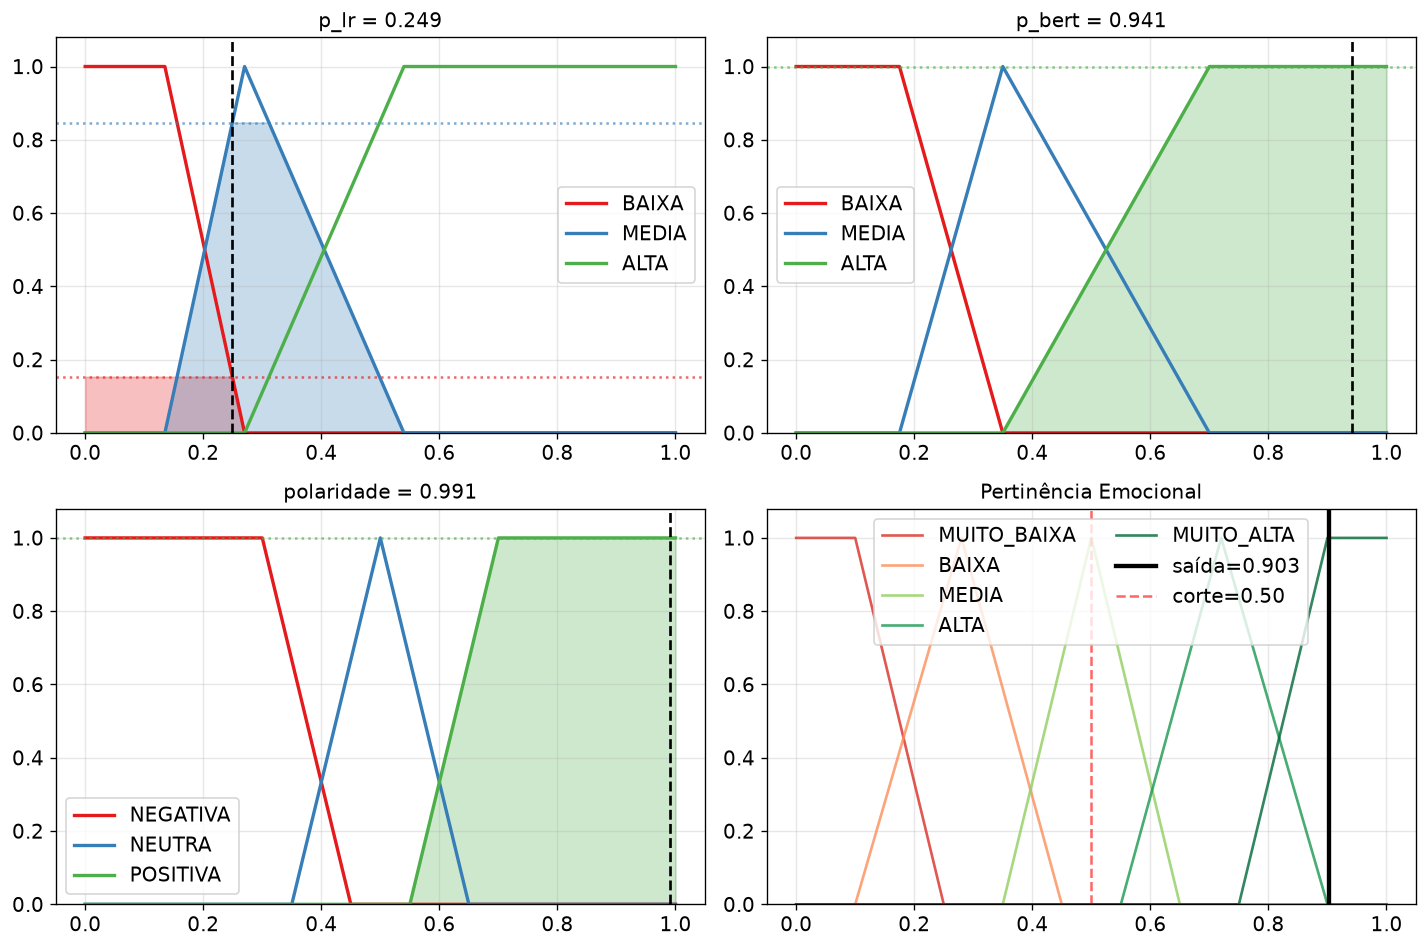


── AUDITORIA: regras disparadas ──


,disparo,origem,regra
1,0.8469,dados,SE p_lr é MEDIA E p_bert é ALTA E polaridade é POSITIVA ENTÃO pertinência é MUITO_ALTA
0,0.1531,dados,SE p_lr é BAIXA E p_bert é ALTA E polaridade é POSITIVA ENTÃO pertinência é MUITO_ALTA


In [ ]:
def visualizar_ativacao(emo, df_reg, p_lr_v, p_bert_v, pol_v, titulo=""):
    sim, (v_lr, v_bert, v_pol, v_pert) = criar_fis(emo, df_reg, 'centroid')
    saida = inferir(emo, df_reg, p_lr_v, p_bert_v, pol_v)

    # Paleta sem amarelo apagado
    PALETA_VARIAVEIS = [
        "#E41A1C",  # vermelho
        "#377EB8",  # azul
        "#4DAF4A",  # verde
        "#984EA3",  # roxo
        "#FF7F00",  # laranja
    ]

    PALETA_PERT = [
        "#D73027",
        "#FC8D59",
        "#91CF60",
        "#1A9850",
        "#006837", 
    ]

    # 2 gráficos em cima e 2 embaixo
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, var, universo, termos, val, nome in [
        (axes[0], v_lr,   U_P,   TERMOS_P,   p_lr_v,   'p_lr'),
        (axes[1], v_bert, U_P,   TERMOS_P,   p_bert_v, 'p_bert'),
        (axes[2], v_pol,  U_POL, TERMOS_POL, pol_v,    'polaridade'),
    ]:

        cores = PALETA_VARIAVEIS[:len(termos)]

        for t, c in zip(termos, cores):

            ax.plot(
                universo,
                var[t].mf,
                color=c,
                linewidth=2,
                label=t
            )

            g = float(np.interp(val, universo, var[t].mf))

            if g > 0.01:
                ax.fill_between(
                    universo,
                    0,
                    np.minimum(var[t].mf, g),
                    color=c,
                    alpha=0.28
                )

                ax.axhline(
                    g,
                    color=c,
                    linestyle=':',
                    alpha=0.65
                )

        ax.axvline(
            val,
            color='black',
            linestyle='--',
            linewidth=1.6
        )

        ax.set_title(
            f'{nome} = {val:.3f}',
            fontsize=12
        )

        ax.set_ylim(0, 1.08)

        ax.legend(fontsize=12)

        ax.grid(True, alpha=0.3)

        ax.tick_params(
            axis='both',
            labelsize=12
        )

    # =====================================================
    # Saída fuzzy
    # =====================================================

    ax = axes[3]

    cores = PALETA_PERT[:len(TERMOS_PERT)]

    for t, c in zip(TERMOS_PERT, cores):

        ax.plot(
            U_PERT,
            v_pert[t].mf,
            color=c,
            linewidth=1.6,
            label=t,
            alpha=0.8
        )

    ax.axvline(
        saida,
        color='black',
        linewidth=2.6,
        label=f'saída={saida:.3f}'
    )

    ax.axvline(
        0.5,
        color='red',
        linestyle='--',
        alpha=0.6,
        label='corte=0.50'
    )

    ax.set_title(
        'Pertinência Emocional',
        fontsize=12
    )

    ax.set_ylim(0, 1.08)

    ax.legend(
        fontsize=12,
        ncol=2
    )

    ax.grid(True, alpha=0.3)

    ax.tick_params(
        axis='both',
        labelsize=12
    )

    plt.tight_layout()
    plt.show()

    return saida


def regras_disparadas(emo, df_reg, p_lr_v, p_bert_v, pol_v, top=5):
    """AUDITORIA: quais regras dispararam e com que força."""
    v_lr   = build_prob_antecedent('p_lr',   tau_lr[emo])
    v_bert = build_prob_antecedent('p_bert', tau_bert[emo])
    v_pol  = build_polaridade()

    linhas = []

    for _, r in df_reg.iterrows():
        g = (
            float(np.interp(p_lr_v, U_P, v_lr[r['t_lr']].mf)) *
            float(np.interp(p_bert_v, U_P, v_bert[r['t_bert']].mf)) *
            float(np.interp(pol_v, U_POL, v_pol[r['t_pol']].mf))
        )

        if g > 1e-4:
            linhas.append({
                'disparo': round(g, 4),
                'origem': r['origem'],
                'regra': (
                    f"SE p_lr é {r['t_lr']} E p_bert é {r['t_bert']} "
                    f"E polaridade é {r['t_pol']} "
                    f"ENTÃO pertinência é {r['t_pert']}"
                )
            })

    return (
        pd.DataFrame(linhas)
        .sort_values('disparo', ascending=False)
        .head(top)
    )


# Demonstração num caso real do fold de teste
j = EMOTION_COLS.index(EMO_BEST)

pos = np.where(
    Y_folds[FOLD_DEMO][:, j] == 1
)[0]

i = int(pos[0])

print(
    f'TEXTO REAL: "{TEXT_folds[FOLD_DEMO][i][:180]}"'
)

print(
    f'Rótulo verdadeiro para {EMO_BEST}: '
    f'{Y_folds[FOLD_DEMO][i, j]}\n'
)


visualizar_ativacao(
    EMO_BEST,
    df_wm_best,
    P_LR_folds[FOLD_DEMO][i, j],
    P_BERT_folds[FOLD_DEMO][i, j],
    POL_folds[FOLD_DEMO][i],
    "— exemplo real (positivo)"
)


print("\n── AUDITORIA: regras disparadas ──")


pd.set_option('display.max_colwidth', None)
display(
    regras_disparadas(
        EMO_BEST,
        df_wm_best,
        P_LR_folds[FOLD_DEMO][i, j],
        P_BERT_folds[FOLD_DEMO][i, j],
        POL_folds[FOLD_DEMO][i]
    )
)

## Superfície de resposta e escolha da defuzzificação

Primeiro a superfície de resposta (como a pertinência varia com `p_lr` e `p_bert`). Em seguida, uma
**análise quantitativa dos métodos de defuzzificação**: em vez de olhar só alguns pontos, avaliamos o
**F1-macro out-of-fold** de cada método sobre todas as emoções, para escolher a defuzzificação por
desempenho e não por preferência. Um motor de inferência vetorizado torna essa varredura viável.

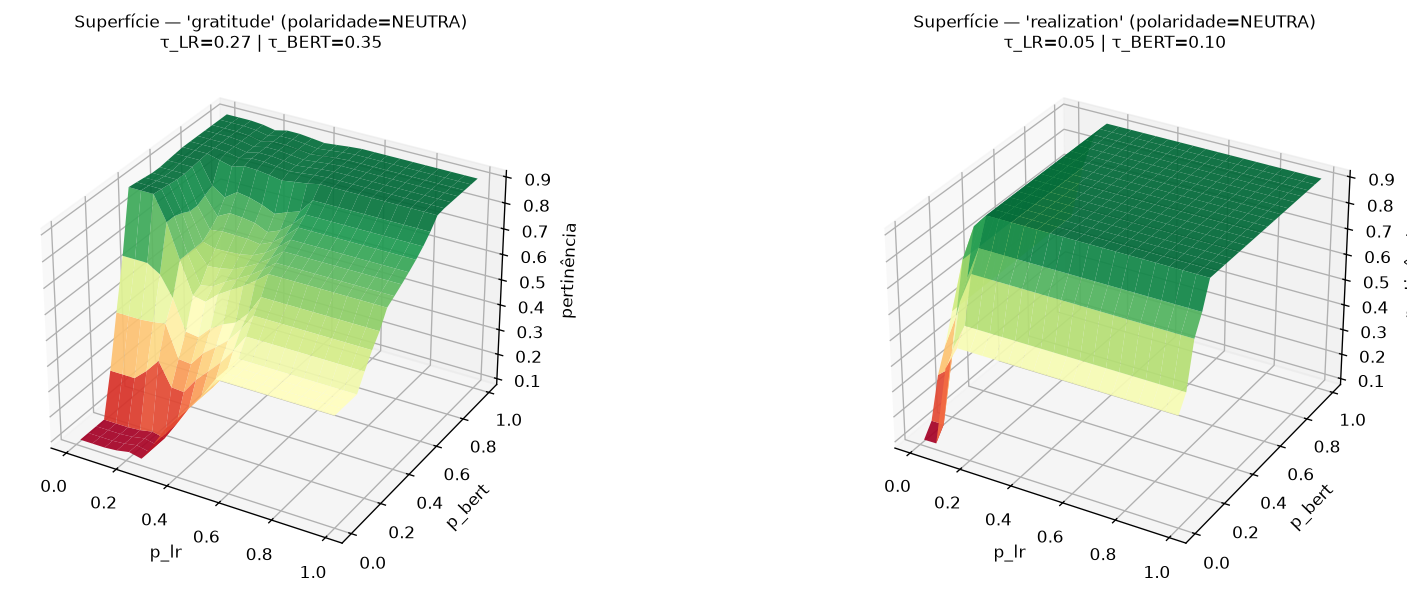

Leitura: o patamar da superfície muda de posição conforme τ.


In [ ]:
# ── Superfície de resposta: p_lr × p_bert → pertinência ──────────
def superficie(emo, df_reg, pol_fix=0.5, n=21):
    gx = np.linspace(0.01, 0.99, n)
    Z = np.zeros((n, n))
    for a, plr in enumerate(gx):
        for b, pbe in enumerate(gx):
            Z[a, b] = inferir(emo, df_reg, plr, pbe, pol_fix)
    return gx, Z

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(16, 5))
for idx, (emo, df_reg) in enumerate([(EMO_BEST, df_wm_best), (EMO_WORST, df_wm_worst)], 1):
    gx, Z = superficie(emo, df_reg)
    X, Ym = np.meshgrid(gx, gx, indexing='ij')
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    ax.plot_surface(X, Ym, Z, cmap='RdYlGn', edgecolor='none', alpha=0.92)
    ax.set_xlabel('p_lr'); ax.set_ylabel('p_bert'); ax.set_zlabel('pertinência')
    ax.set_title(f"Superfície — '{emo}' (polaridade=NEUTRA)\n"
                 f"τ_LR={tau_lr[emo]:.2f} | τ_BERT={tau_bert[emo]:.2f}", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_INTERP / "superficies.png", dpi=180, bbox_inches='tight')
plt.show()
print("Leitura: o patamar da superfície muda de posição conforme τ.")

### Comparação dos métodos de defuzzificação por F1 (out-of-fold)

Para cada método, o ensemble produz a pertinência de cada mensagem (regras de Wang–Mendel extraídas
**fora do fold**), calibra o limiar sobre a pertinência nos outros 4 folds e mede o F1 no fold de
teste. Um motor de inferência Mamdani **vetorizado** (equivalente ao `skfuzzy`, porém sobre todas as
amostras de uma vez) torna a varredura de todos os métodos e folds rápida.

In [ ]:
# ── Motor Mamdani vetorizado (equivalente ao skfuzzy; usado só na avaliação) ──
_DU = float(U_PERT[1] - U_PERT[0])
_PERT_MFS = None
def _pert_mfs():
    global _PERT_MFS
    if _PERT_MFS is None:
        v = build_pertinencia(); _PERT_MFS = {t: v[t].mf for t in TERMOS_PERT}
    return _PERT_MFS

_ANTE = {}
def _antecedentes(emo):
    if emo not in _ANTE:
        v_lr = build_prob_antecedent('p_lr', tau_lr[emo])
        v_be = build_prob_antecedent('p_bert', tau_bert[emo])
        v_po = build_polaridade()
        _ANTE[emo] = ({t: v_lr[t].mf for t in TERMOS_P},
                      {t: v_be[t].mf for t in TERMOS_P},
                      {t: v_po[t].mf for t in TERMOS_POL})
    return _ANTE[emo]

def _agregado(emo, df_reg, p_lr, p_be, pol):
    mf_lr, mf_be, mf_po = _antecedentes(emo); pert = _pert_mfs()
    p_lr = np.clip(np.asarray(p_lr, float), 0, 1)
    p_be = np.clip(np.asarray(p_be, float), 0, 1)
    pol  = np.clip(np.asarray(pol,  float), 0, 1)
    m_lr = {t: np.interp(p_lr, U_P,   mf) for t, mf in mf_lr.items()}
    m_be = {t: np.interp(p_be, U_P,   mf) for t, mf in mf_be.items()}
    m_po = {t: np.interp(pol,  U_POL, mf) for t, mf in mf_po.items()}
    agg = np.zeros((len(p_lr), len(U_PERT)), dtype=np.float32)
    for _, r in df_reg.iterrows():
        w = np.minimum(np.minimum(m_lr[r['t_lr']], m_be[r['t_bert']]), m_po[r['t_pol']])
        if w.max() <= 0:
            continue
        np.maximum(agg, np.minimum(pert[r['t_pert']][None, :], w[:, None]), out=agg)
    return agg

def _defuzz(agg, method):
    den = agg.sum(1); empty = den <= 1e-12
    if method == 'centroid':
        out = np.where(~empty, (agg * U_PERT[None, :]).sum(1) / np.maximum(den, 1e-12), 0.0)
    elif method == 'bisector':
        cs = np.cumsum(agg, axis=1) * _DU
        out = U_PERT[(cs >= (cs[:, -1] / 2.0)[:, None]).argmax(1)]
    elif method in ('mom', 'som', 'lom'):
        mx = agg.max(1, keepdims=True); ismax = (agg >= mx - 1e-9) & (mx > 1e-12)
        out = np.zeros(len(agg))
        for i in range(len(agg)):
            pts = U_PERT[ismax[i]]
            out[i] = 0.0 if len(pts) == 0 else (pts.mean() if method == 'mom'
                                                else pts.min() if method == 'som' else pts.max())
    else:
        raise ValueError(method)
    return np.where(empty, 0.0, out)

def inferir_lote(emo, df_reg, p_lr, p_be, pol, defuzz='centroid'):
    return _defuzz(_agregado(emo, df_reg, p_lr, p_be, pol), defuzz)

# ── F1-macro OOF por método de defuzzificação ─────────────────────
EVAL_CACHE = OUT_INTERP / "cache_defuzz"
EVAL_CACHE.mkdir(parents=True, exist_ok=True)

METODOS_DEFUZZ = ['centroid', 'bisector', 'mom', 'som', 'lom']
NOMES_DEFUZZ = {'centroid': 'Centroide', 'bisector': 'Bissecção',
                'mom': 'Média Máximos', 'som': 'Menor Máximo', 'lom': 'Maior Máximo'}

def pertinencia_oof(defuzz):
    out = {}
    for k in folds_data:
        fp = EVAL_CACHE / f"PERT_{defuzz}_fold{k}.npy"
        if fp.exists():
            out[k] = np.load(fp); continue
        M = np.zeros((len(Y_folds[k]), N_LABELS), dtype=np.float32)
        for j, emo in enumerate(EMOTION_COLS):
            df_reg = wang_mendel(emo, fold_demo=k)           # regras fora do fold k
            M[:, j] = inferir_lote(emo, df_reg,
                                   P_LR_folds[k][:, j], P_BERT_folds[k][:, j], POL_folds[k],
                                   defuzz=defuzz)
        np.save(fp, M); out[k] = M
        print(f"    [{defuzz}] fold {k} ok")
    return out

resultado_defuzz = {}
for dz in METODOS_DEFUZZ:
    print(f"\nDefuzzificação: {NOMES_DEFUZZ[dz]}")
    PERT = pertinencia_oof(dz)
    f1f, f1lab = [], []
    for k in folds_data:
        train_ks = [j for j in folds_data if j != k]
        thr = calibrate_thresholds(np.vstack([PERT[j] for j in train_ks]),
                                   np.vstack([Y_folds[j] for j in train_ks]), THRESH_GRID)[0]
        yp = (PERT[k] >= thr[None, :]).astype(int)
        f1f.append(f1_score(Y_folds[k], yp, average='macro', zero_division=0))
        f1lab.append(f1_score(Y_folds[k], yp, average=None, zero_division=0))
    resultado_defuzz[dz] = {'f1_folds': np.array(f1f), 'f1_lab': np.mean(f1lab, axis=0)}
    print(f"  F1-macro OOF = {np.mean(f1f):.4f} ± {np.std(f1f):.4f}")

melhor_dz = max(resultado_defuzz, key=lambda d: resultado_defuzz[d]['f1_folds'].mean())
print(f"\n✓ Melhor defuzzificação por F1-macro: {NOMES_DEFUZZ[melhor_dz]} "
      f"({resultado_defuzz[melhor_dz]['f1_folds'].mean():.4f})")


Defuzzificação: Centroide
    [centroid] fold 1 ok
    [centroid] fold 2 ok
    [centroid] fold 3 ok
    [centroid] fold 4 ok
    [centroid] fold 5 ok
  F1-macro OOF = 0.4684 ± 0.0068

Defuzzificação: Bissecção
    [bisector] fold 1 ok
    [bisector] fold 2 ok
    [bisector] fold 3 ok
    [bisector] fold 4 ok
    [bisector] fold 5 ok
  F1-macro OOF = 0.4687 ± 0.0064

Defuzzificação: Média Máximos
    [mom] fold 1 ok
    [mom] fold 2 ok
    [mom] fold 3 ok
    [mom] fold 4 ok
    [mom] fold 5 ok
  F1-macro OOF = 0.4634 ± 0.0054

Defuzzificação: Menor Máximo
    [som] fold 1 ok
    [som] fold 2 ok
    [som] fold 3 ok
    [som] fold 4 ok
    [som] fold 5 ok
  F1-macro OOF = 0.4635 ± 0.0058

Defuzzificação: Maior Máximo
    [lom] fold 1 ok
    [lom] fold 2 ok
    [lom] fold 3 ok
    [lom] fold 4 ok
    [lom] fold 5 ok
  F1-macro OOF = 0.4632 ± 0.0050

✓ Melhor defuzzificação por F1-macro: Bissecção (0.4687)


════════════════════════════════════════════════════════
MÉTODOS DE DEFUZZIFICAÇÃO — F1-macro OOF
════════════════════════════════════════════════════════


,F1-macro,desvio
Centroide,0.4684,0.0068
Bissecção,0.4687,0.0064
Média Máximos,0.4634,0.0054
Menor Máximo,0.4635,0.0058
Maior Máximo,0.4632,0.0050


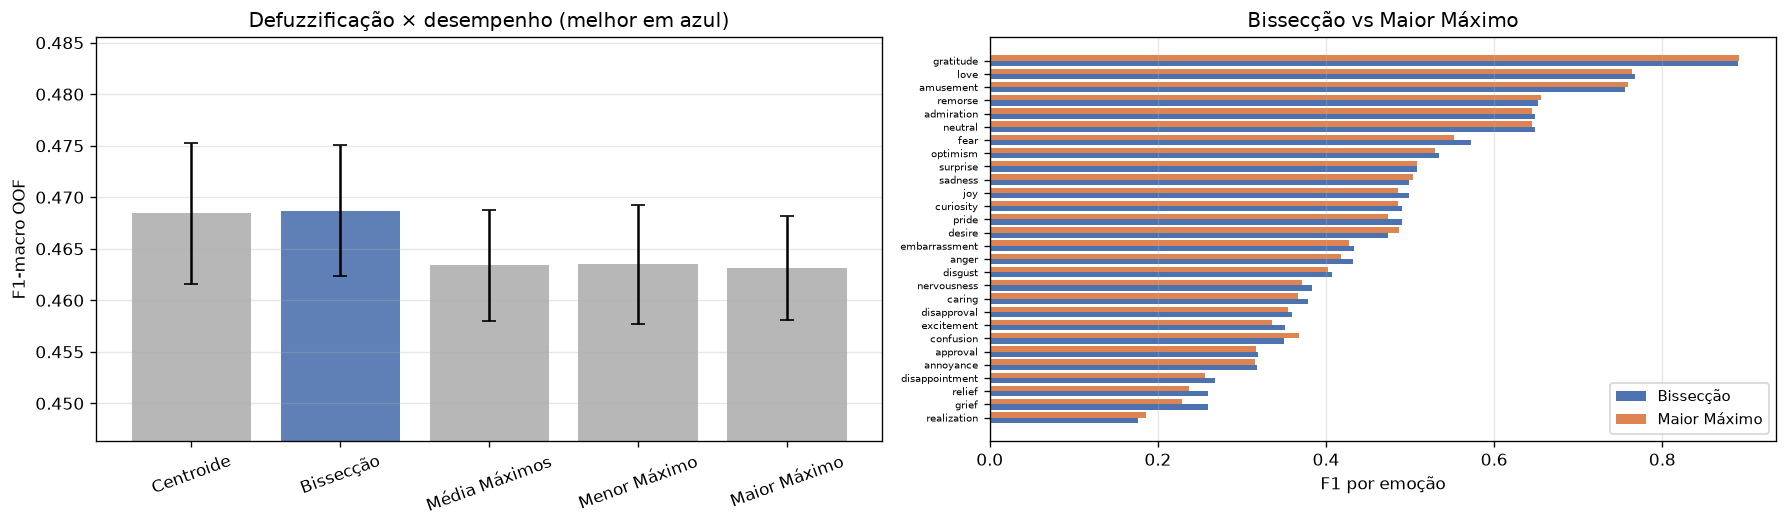


===== Pertinência em pontos-chave — emoção 'gratitude' =====


Defuzz,Bissecção,Centroide,Maior Máximo,Menor Máximo,Média Máximos
Cenário,,,,,
"Ambos altos, pol. negativa",0.913,0.907,1.0,0.9,0.95
"Ambos altos, pol. neutra",0.913,0.907,1.0,0.9,0.95
"Ambos altos, pol. positiva",0.913,0.907,1.0,0.9,0.95
Ambos discordam (baixo),0.087,0.093,0.1,0.0,0.05
"LR alto, BERT baixo",0.500,0.500,0.5,0.5,0.50
"LR baixo, BERT alto",0.913,0.907,1.0,0.9,0.95
Zona de dúvida (≈τ),0.500,0.500,0.5,0.5,0.50


A divergência entre métodos concentra-se na zona de dúvida; nos extremos eles concordam.

→ Defuzzificação adotada nos cenários: Bissecção


In [ ]:
# ── Tabela-resumo e GRÁFICO da comparação de defuzzificação ───────
tab = pd.DataFrame({
    NOMES_DEFUZZ[dz]: {
        "F1-macro": resultado_defuzz[dz]['f1_folds'].mean(),
        "desvio":   resultado_defuzz[dz]['f1_folds'].std(),
    } for dz in METODOS_DEFUZZ
}).T.round(4)
print("═" * 56)
print("MÉTODOS DE DEFUZZIFICAÇÃO — F1-macro OOF")
print("═" * 56)
display(tab)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# (esq.) barras de F1-macro por método, com desvio entre folds
ax = axes[0]
nomes = [NOMES_DEFUZZ[d] for d in METODOS_DEFUZZ]
med   = [resultado_defuzz[d]['f1_folds'].mean() for d in METODOS_DEFUZZ]
desv  = [resultado_defuzz[d]['f1_folds'].std()  for d in METODOS_DEFUZZ]
cores = ["#4C72B0" if d == melhor_dz else "#B0B0B0" for d in METODOS_DEFUZZ]
ax.bar(nomes, med, yerr=desv, capsize=4, color=cores, alpha=0.9)
ax.set_ylabel("F1-macro OOF"); ax.set_title("Defuzzificação × desempenho (melhor em azul)")
ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)
lo = min(med) - max(desv) - 0.01
ax.set_ylim(max(0, lo), max(med) + max(desv) + 0.01)

# (dir.) F1 por emoção: melhor método vs pior método (mostra ONDE diverge)
ax = axes[1]
pior_dz = min(resultado_defuzz, key=lambda d: resultado_defuzz[d]['f1_folds'].mean())
s_best = pd.Series(resultado_defuzz[melhor_dz]['f1_lab'], index=EMOTION_COLS)
s_worst = pd.Series(resultado_defuzz[pior_dz]['f1_lab'], index=EMOTION_COLS)
ordem = s_best.sort_values().index
y = np.arange(len(ordem))
ax.barh(y - 0.2, s_best[ordem].values, 0.4, label=NOMES_DEFUZZ[melhor_dz], color="#4C72B0")
ax.barh(y + 0.2, s_worst[ordem].values, 0.4, label=NOMES_DEFUZZ[pior_dz], color="#DD8452")
ax.set_yticks(y); ax.set_yticklabels(ordem, fontsize=6)
ax.set_xlabel("F1 por emoção"); ax.set_title(f"{NOMES_DEFUZZ[melhor_dz]} vs {NOMES_DEFUZZ[pior_dz]}")
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_INTERP / "defuzzificacao_comparacao.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabela de sensibilidade em pontos-chave (mantida, agora com o motor rápido) ──
pontos = [
    ("Ambos discordam (baixo)",    0.05, 0.02, 0.50),
    ("LR alto, BERT baixo",        0.80, 0.05, 0.50),
    ("LR baixo, BERT alto",        0.05, 0.80, 0.50),
    ("Ambos altos, pol. neutra",   0.80, 0.80, 0.50),
    ("Ambos altos, pol. positiva", 0.80, 0.80, 0.90),
    ("Ambos altos, pol. negativa", 0.80, 0.80, 0.10),
    ("Zona de dúvida (≈τ)",        float(tau_lr[EMO_BEST]), float(tau_bert[EMO_BEST]), 0.50),
]
linhas = []
for nome, plr, pbe, pl in pontos:
    for dz in METODOS_DEFUZZ:
        v = float(inferir_lote(EMO_BEST, df_wm_best, [plr], [pbe], [pl], defuzz=dz)[0])
        linhas.append({"Cenário": nome, "Defuzz": NOMES_DEFUZZ[dz], "Pertinência": round(v, 3)})
df_dz = pd.DataFrame(linhas)
print(f"\n===== Pertinência em pontos-chave — emoção '{EMO_BEST}' =====")
display(df_dz.pivot(index="Cenário", columns="Defuzz", values="Pertinência"))
print("A divergência entre métodos concentra-se na zona de dúvida; nos extremos eles concordam.")

DEFUZZ_FINAL = melhor_dz
print(f"\n→ Defuzzificação adotada nos cenários: {NOMES_DEFUZZ[DEFUZZ_FINAL]}")

## Cenários: mensagens de pacientes

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CENÁRIOS DE APLICAÇÃO — consultor monitorando mensagens de pacientes
#
# Mensagens REAIS do conjunto de teste (fold 1), selecionadas por palavras-chave
# do domínio. Aproveitam as probabilidades OOF já calculadas — nenhum modelo é
# reexecutado, e nenhuma mensagem foi vista no treino do fold.
# ══════════════════════════════════════════════════════════════════
CACHE_REGRAS = {EMO_BEST: df_wm_best, EMO_WORST: df_wm_worst}

def maf_de(emo, fold):
    if emo not in CACHE_REGRAS:
        CACHE_REGRAS[emo] = wang_mendel(emo, fold_demo=fold)
    return CACHE_REGRAS[emo]

def perfil_emocional(fold, i, corte=0.5, top=6):
    """Roda os 28 FIS para uma mensagem e devolve o perfil de pertinência."""
    graus = {}
    for j, emo in enumerate(EMOTION_COLS):
        graus[emo] = inferir(emo, maf_de(emo, fold),
                             P_LR_folds[fold][i, j], P_BERT_folds[fold][i, j],
                             POL_folds[fold][i], defuzz=DEFUZZ_FINAL)
    s = pd.Series(graus).sort_values(ascending=False)
    return s.head(top), s[s >= corte].index.tolist()

PALAVRAS = ['sozinh', 'ansios', 'não aguento', 'nao aguento', 'cansad', 'medo',
            'triste', 'obrigad', 'ajuda', 'melhor', 'esperança', 'esperanca']
textos = TEXT_folds[FOLD_DEMO]
cands = [i for i, t in enumerate(textos)
         if any(p in t.lower() for p in PALAVRAS) and 25 < len(t) < 160]
print(f"Mensagens candidatas encontradas: {len(cands)}")

N_CENARIOS = 4
for c, i in enumerate(cands[:N_CENARIOS], 1):
    print("\n" + "═" * 66); print(f"CENÁRIO {c}"); print("═" * 66)
    print(f'Mensagem: "{textos[i]}"')
    reais = [e for e in EMOTION_COLS if Y_folds[FOLD_DEMO][i, EMOTION_COLS.index(e)] == 1]
    print(f'Emoções anotadas (verdade): {reais}')
    print(f'Polaridade léxica: {POL_folds[FOLD_DEMO][i]:.2f}')
    perfil, sinalizadas = perfil_emocional(FOLD_DEMO, i)
    print('\nPerfil de pertinência (top 6):')
    for emo, g in perfil.items():
        barra = '█' * int(g * 30); marca = '←' if emo in reais else ' '
        print(f'  {emo:15s} {g:.3f} |{barra:<30}| {marca}')
    print(f'\nEmoções sinalizadas ao consultor (pertinência ≥ 0.50): {sinalizadas}')

Mensagens candidatas encontradas: 984

══════════════════════════════════════════════════════════════════
CENÁRIO 1
══════════════════════════════════════════════════════════════════
Mensagem: "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"
Emoções anotadas (verdade): ['caring', 'joy']
Polaridade léxica: 0.95

Perfil de pertinência (top 6):
  joy             0.905 |███████████████████████████   | ←
  caring          0.480 |██████████████                | ←
  admiration      0.292 |████████                      |  
  approval        0.218 |██████                        |  
  excitement      0.103 |███                           |  
  anger           0.087 |██                            |  

Emoções sinalizadas ao consultor (pertinência ≥ 0.50): ['joy']

══════════════════════════════════════════════════════════════════
CENÁRIO 2
══════════════════════════════════════════════════════════════════
Mensagem: "sim saude esperando que seja melhor feliz inicio ano p

## Auditoria completa de um caso

In [ ]:
i = cands[0]
EMO_AUDIT = EMO_BEST
j = EMOTION_COLS.index(EMO_AUDIT)

plr = float(P_LR_folds[FOLD_DEMO][i, j])
pbe = float(P_BERT_folds[FOLD_DEMO][i, j])
pol = float(POL_folds[FOLD_DEMO][i])

print("═" * 66); print(f"AUDITORIA COMPLETA — emoção '{EMO_AUDIT}'"); print("═" * 66)
print(f'\n[1] MENSAGEM\n    "{textos[i]}"')
print(f'\n[2] ENTRADAS CRISP')
print(f'    p_lr       = {plr:.4f}  (τ_LR   = {tau_lr[EMO_AUDIT]:.2f})')
print(f'    p_bert     = {pbe:.4f}  (τ_BERT = {tau_bert[EMO_AUDIT]:.2f})')
print(f'    polaridade = {pol:.4f}')

v_lr   = build_prob_antecedent('p_lr',   tau_lr[EMO_AUDIT])
v_bert = build_prob_antecedent('p_bert', tau_bert[EMO_AUDIT])
v_pol  = build_polaridade()
print(f'\n[3] FUZZIFICAÇÃO')
for nome, var, universo, termos, val in [
    ('p_lr',       v_lr,   U_P,   TERMOS_P,   plr),
    ('p_bert',     v_bert, U_P,   TERMOS_P,   pbe),
    ('polaridade', v_pol,  U_POL, TERMOS_POL, pol),
]:
    graus = {t: round(float(np.interp(val, universo, var[t].mf)), 3) for t in termos}
    print(f'    {nome:11s}: {graus}')

print(f'\n[4] REGRAS DISPARADAS')
display(regras_disparadas(EMO_AUDIT, df_wm_best, plr, pbe, pol, top=5))

g = inferir(EMO_AUDIT, df_wm_best, plr, pbe, pol, defuzz=DEFUZZ_FINAL)
print(f'\n[5] DEFUZZIFICAÇÃO ({NOMES_DEFUZZ[DEFUZZ_FINAL]})\n    pertinência = {g:.4f}')
decidiu = g >= 0.5
print(f'\n[6] DECISÃO\n    {"SINALIZAR" if decidiu else "não sinalizar"} '
      f'(corte=0.50) | verdade = {Y_folds[FOLD_DEMO][i, j]}')

# explicação COERENTE com a decisão (sem texto fixo)
acao = "sinalizada" if decidiu else "NÃO sinalizada"
ev   = "ALTA" if pbe > tau_bert[EMO_AUDIT] else "BAIXA"
rel  = "acima" if pbe > tau_bert[EMO_AUDIT] else "abaixo"
print(f'\n[7] EXPLICAÇÃO AO CONSULTOR')
print(f'    "A mensagem foi {acao} como {EMO_AUDIT}. O BERTimbau atribuiu evidência {ev}\n'
      f'     ({rel} do ponto de decisão {tau_bert[EMO_AUDIT]:.2f}); o léxico indicou\n'
      f'     polaridade {pol:.2f}; e a regra de maior disparo na base concluiu\n'
      f'     pertinência {g:.2f}."')

══════════════════════════════════════════════════════════════════
AUDITORIA COMPLETA — emoção 'gratitude'
══════════════════════════════════════════════════════════════════

[1] MENSAGEM
    "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"

[2] ENTRADAS CRISP
    p_lr       = 0.0655  (τ_LR   = 0.27)
    p_bert     = 0.0877  (τ_BERT = 0.35)
    polaridade = 0.9458

[3] FUZZIFICAÇÃO
    p_lr       : {'BAIXA': 1.0, 'MEDIA': 0.0, 'ALTA': 0.0}
    p_bert     : {'BAIXA': 1.0, 'MEDIA': 0.0, 'ALTA': 0.0}
    polaridade : {'NEGATIVA': 0.0, 'NEUTRA': 0.0, 'POSITIVA': 1.0}

[4] REGRAS DISPARADAS


,disparo,origem,regra
0,1.0,dados,SE p_lr é BAIXA E p_bert é BAIXA E polaridade é POSITIVA ENTÃO pertinência é MUITO_BAIXA



[5] DEFUZZIFICAÇÃO (Bissecção)
    pertinência = 0.0875

[6] DECISÃO
    não sinalizar (corte=0.50) | verdade = 0

[7] EXPLICAÇÃO AO CONSULTOR
    "A mensagem foi NÃO sinalizada como gratitude. O BERTimbau atribuiu evidência BAIXA
     (abaixo do ponto de decisão 0.35); o léxico indicou
     polaridade 0.95; e a regra de maior disparo na base concluiu
     pertinência 0.09."


════════════════════════════════════════════════════════════════════
COMPARAÇÃO FINAL — média ± desvio entre os 5 folds (OOF)
════════════════════════════════════════════════════════════════════


,precision_macro,recall_macro,f1_macro
LR @limiar,0.2847 ± 0.0069,0.3311 ± 0.0095,0.2840 ± 0.0040
BERT @limiar,0.4543 ± 0.0061,0.4884 ± 0.0054,0.4655 ± 0.0041
Ensemble Fuzzy (Bissecção),0.4643 ± 0.0119,0.4946 ± 0.0083,0.4687 ± 0.0064


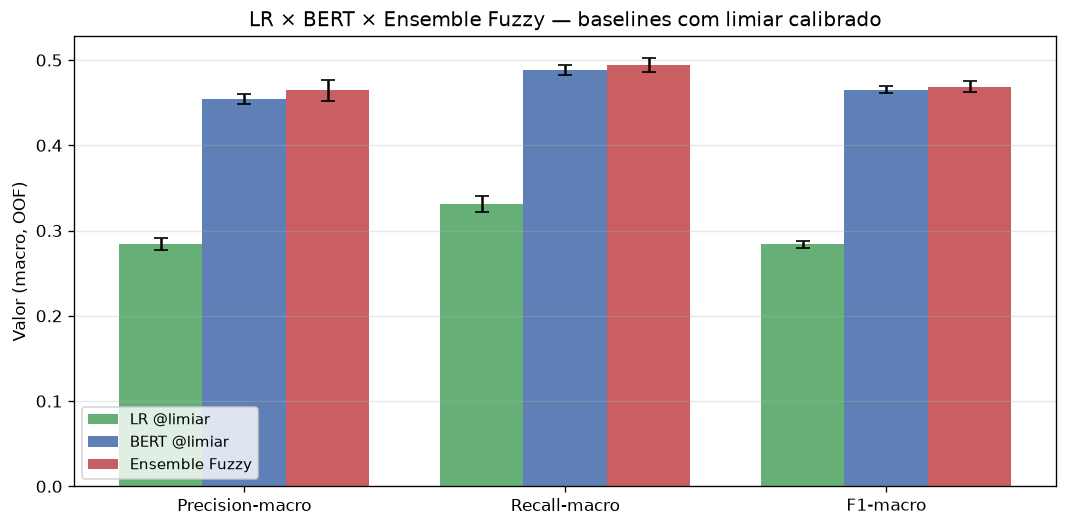


Wilcoxon pareado (F1-macro, por fold):
  Ensemble Fuzzy vs BERT @limiar  : Δ=+0.0033 | W=3.0, p=0.3125
  Ensemble Fuzzy vs LR @limiar    : Δ=+0.1847 | W=0.0, p=0.0625


In [ ]:
# ══════════════════════════════════════════════════════════════════
# COMPARAÇÃO: LR@tuned × BERT@tuned × Ensemble Fuzzy
# (precision-macro, recall-macro, F1-macro — todos OOF, mesmo protocolo)
# ══════════════════════════════════════════════════════════════════
PERT_final = pertinencia_oof(DEFUZZ_FINAL)   # cacheado; não recomputa

# métricas do Ensemble Fuzzy, fold a fold (limiar sobre a pertinência, calibrado fora do fold)
ens_p, ens_r, ens_f1 = [], [], []
for k in folds_data:
    train_ks = [j for j in folds_data if j != k]
    thr = calibrate_thresholds(np.vstack([PERT_final[j] for j in train_ks]),
                               np.vstack([Y_folds[j]    for j in train_ks]), THRESH_GRID)[0]
    yp = (PERT_final[k] >= thr[None, :]).astype(int)
    ens_p.append(precision_score(Y_folds[k], yp, average="macro", zero_division=0))
    ens_r.append(recall_score(   Y_folds[k], yp, average="macro", zero_division=0))
    ens_f1.append(f1_score(      Y_folds[k], yp, average="macro", zero_division=0))
ens_p, ens_r, ens_f1 = map(np.array, (ens_p, ens_r, ens_f1))

# baselines calibrados: reusa os resultados por fold já calculados na Parte 0 (dfs)
def _mean_std(vals):
    return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"

comparacao = pd.DataFrame({
    "LR @limiar": {
        "precision_macro": _mean_std(dfs["LR@tuned"]["precision_macro"].values),
        "recall_macro":    _mean_std(dfs["LR@tuned"]["recall_macro"].values),
        "f1_macro":        _mean_std(dfs["LR@tuned"]["f1_macro"].values),
    },
    "BERT @limiar": {
        "precision_macro": _mean_std(dfs["BERT@tuned"]["precision_macro"].values),
        "recall_macro":    _mean_std(dfs["BERT@tuned"]["recall_macro"].values),
        "f1_macro":        _mean_std(dfs["BERT@tuned"]["f1_macro"].values),
    },
    f"Ensemble Fuzzy ({NOMES_DEFUZZ[DEFUZZ_FINAL]})": {
        "precision_macro": _mean_std(ens_p),
        "recall_macro":    _mean_std(ens_r),
        "f1_macro":        _mean_std(ens_f1),
    },
}).T

print("═" * 68)
print("COMPARAÇÃO FINAL — média ± desvio entre os 5 folds (OOF)")
print("═" * 68)
display(comparacao)

# gráfico de barras agrupadas
metricas = ["precision_macro", "recall_macro", "f1_macro"]
rotulos  = ["Precision-macro", "Recall-macro", "F1-macro"]
modelos  = {
    "LR @limiar":   (dfs["LR@tuned"]["precision_macro"], dfs["LR@tuned"]["recall_macro"],   dfs["LR@tuned"]["f1_macro"]),
    "BERT @limiar": (dfs["BERT@tuned"]["precision_macro"], dfs["BERT@tuned"]["recall_macro"], dfs["BERT@tuned"]["f1_macro"]),
    f"Ensemble Fuzzy": (ens_p, ens_r, ens_f1),
}
cores = {"LR @limiar": "#55A868", "BERT @limiar": "#4C72B0", "Ensemble Fuzzy": "#C44E52"}

x = np.arange(len(metricas)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 4.5))
for idx, (nome, vals) in enumerate(modelos.items()):
    med = [np.mean(v) for v in vals]; des = [np.std(v) for v in vals]
    ax.bar(x + (idx - 1) * w, med, w, yerr=des, capsize=4, label=nome, color=cores[nome], alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(rotulos)
ax.set_ylabel("Valor (macro, OOF)")
ax.set_title("LR × BERT × Ensemble Fuzzy — baselines com limiar calibrado")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_INTERP / "comparacao_lr_bert_fuzzy.png", dpi=180, bbox_inches="tight")
plt.show()

comparacao.to_csv(OUT_INTERP / "comparacao_lr_bert_fuzzy.csv")

# teste de Wilcoxon pareado do F1-macro (n=5 folds; menor p possível ≈ 0.0625)
print("\nWilcoxon pareado (F1-macro, por fold):")
for base, nome in [(dfs["BERT@tuned"]["f1_macro"].values, "BERT @limiar"),
                   (dfs["LR@tuned"]["f1_macro"].values,   "LR @limiar")]:
    try:
        s, p = wilcoxon(ens_f1, base)
        print(f"  Ensemble Fuzzy vs {nome:14s}: Δ={ens_f1.mean()-base.mean():+.4f} | W={s:.1f}, p={p:.4f}")
    except ValueError as e:
        print(f"  Ensemble Fuzzy vs {nome:14s}: Δ={ens_f1.mean()-base.mean():+.4f} | Wilcoxon N/A ({e})")


══════════════════════════════════════════════════════════════════
CENÁRIO 1
══════════════════════════════════════════════════════════════════


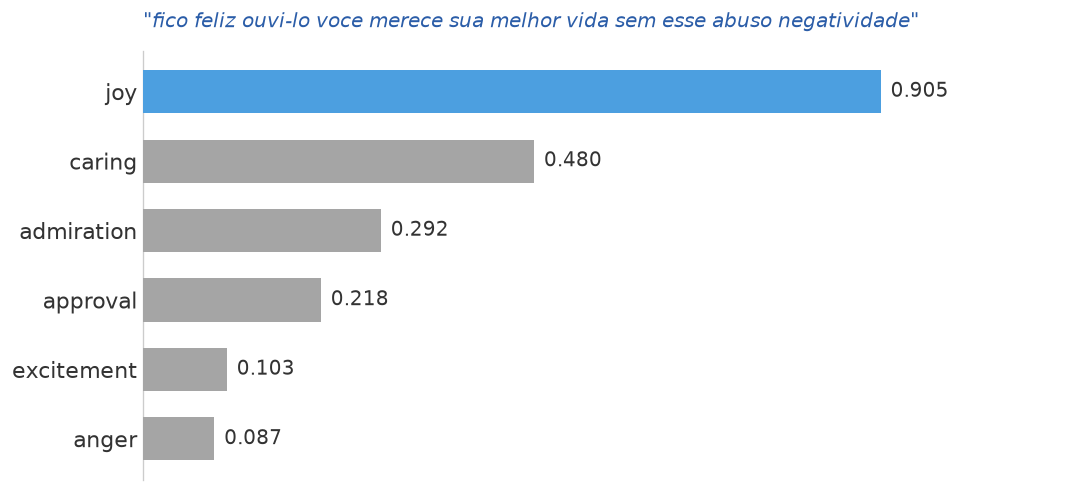

  EMOÇÕES ANOTADAS (VERDADE) : ['caring', 'joy']
  SINALIZADAS AO CONSULTOR   : ['joy']
  POLARIDADE LÉXICA          : 0.95

══════════════════════════════════════════════════════════════════
CENÁRIO 2
══════════════════════════════════════════════════════════════════


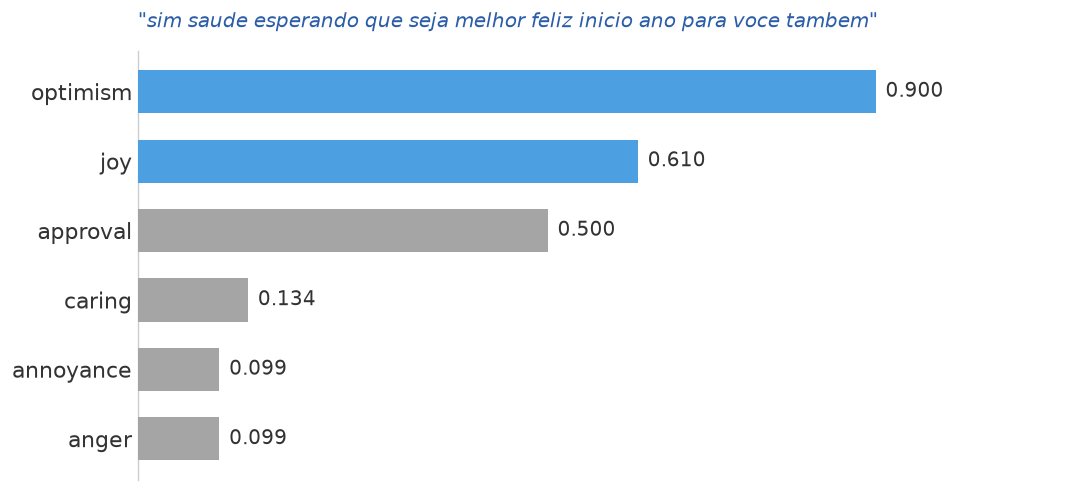

  EMOÇÕES ANOTADAS (VERDADE) : ['joy', 'optimism']
  SINALIZADAS AO CONSULTOR   : ['optimism', 'joy']
  POLARIDADE LÉXICA          : 0.65

══════════════════════════════════════════════════════════════════
CENÁRIO 3
══════════════════════════════════════════════════════════════════


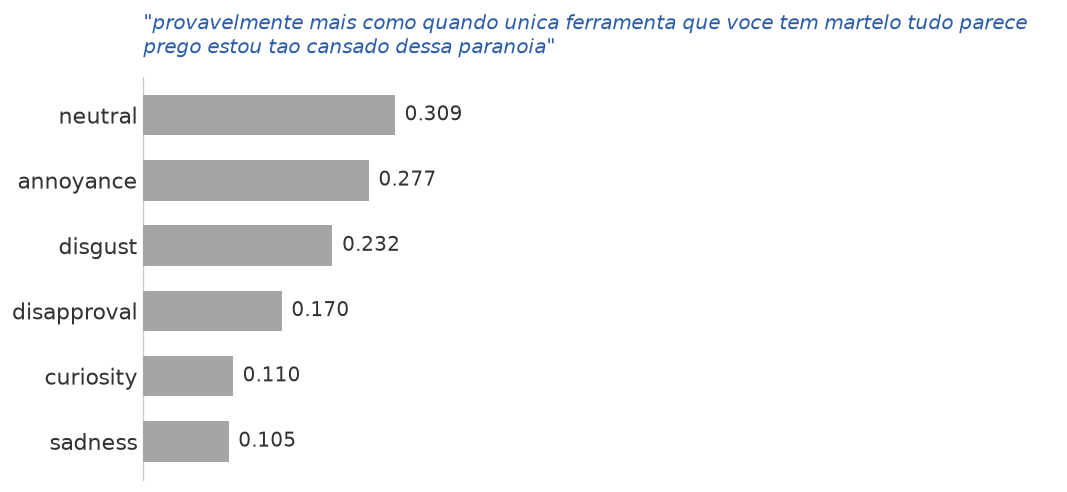

  EMOÇÕES ANOTADAS (VERDADE) : ['sadness']
  SINALIZADAS AO CONSULTOR   : ['nenhuma']
  POLARIDADE LÉXICA          : 0.01

══════════════════════════════════════════════════════════════════
CENÁRIO 4
══════════════════════════════════════════════════════════════════


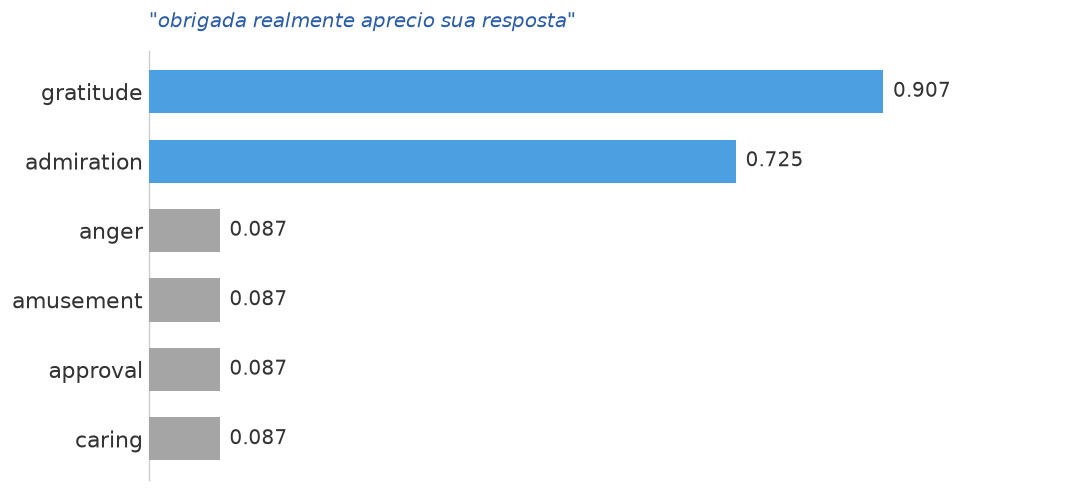

  EMOÇÕES ANOTADAS (VERDADE) : ['admiration', 'gratitude']
  SINALIZADAS AO CONSULTOR   : ['gratitude', 'admiration']
  POLARIDADE LÉXICA          : 0.99


In [30]:
# ══════════════════════════════════════════════════════════════════
# GRÁFICO DOS CENÁRIOS (estilo do slide) — barras horizontais top-6
# azul = sinalizada (pertinência ≥ corte) | cinza = demais
# ══════════════════════════════════════════════════════════════════
AZUL, CINZA = "#4C9FE0", "#A5A5A5"
CORTE = 0.50

def grafico_cenario(fold, i, top=6, corte=CORTE, salvar=True):
    perfil, sinalizadas = perfil_emocional(fold, i, corte=corte, top=top)
    emos  = list(perfil.index)
    vals  = list(perfil.values)
    cores = [AZUL if e in sinalizadas else CINZA for e in emos]

    # maior valor no topo → plota em ordem invertida (menor embaixo)
    emos_r, vals_r, cores_r = emos[::-1], vals[::-1], cores[::-1]

    fig, ax = plt.subplots(figsize=(9, 4.2))
    y = np.arange(len(emos_r))
    ax.barh(y, vals_r, height=0.62, color=cores_r, zorder=3)

    # rótulo de valor à direita de cada barra
    for yi, v in zip(y, vals_r):
        ax.text(v + 0.012, yi, f"{v:.3f}", va="center", ha="left",
                fontsize=12, color="#333333")

    ax.set_yticks(y)
    ax.set_yticklabels(emos_r, fontsize=13, color="#333333")
    ax.set_xlim(0, 1.12)
    ax.set_xticks([])
    for lado in ("top", "right", "bottom"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.tick_params(length=0)

    # título = a mensagem (como no slide)
    ax.set_title(f'"{textos[i]}"', fontsize=12, style="italic",
                 color="#2B5DA8", loc="left", pad=14, wrap=True)

    plt.tight_layout()
    if salvar:
        plt.savefig(OUT_INTERP / f"cenario_{i}_grafico.png", dpi=180, bbox_inches="tight")
    plt.show()

    # painel-texto ao lado (verdade / sinalizadas / polaridade), como no slide
    reais = [e for e in EMOTION_COLS if Y_folds[fold][i, EMOTION_COLS.index(e)] == 1]
    print(f"  EMOÇÕES ANOTADAS (VERDADE) : {reais}")
    print(f"  SINALIZADAS AO CONSULTOR   : {sinalizadas if sinalizadas else ['nenhuma']}")
    print(f"  POLARIDADE LÉXICA          : {POL_folds[fold][i]:.2f}")

# gera um gráfico por cenário (mesmos cands usados na seção de cenários)
for c, i in enumerate(cands[:N_CENARIOS], 1):
    print("\n" + "═" * 66)
    print(f"CENÁRIO {c}")
    print("═" * 66)
    grafico_cenario(FOLD_DEMO, i)

## Exportação e conclusões

In [27]:
df_wm_best.to_csv(OUT_INTERP / f"maf_dados_{EMO_BEST}.csv", index=False)
df_wm_worst.to_csv(OUT_INTERP / f"maf_dados_{EMO_WORST}.csv", index=False)
gerar_maf_especialista(EMO_BEST).to_csv(OUT_INTERP / f"maf_especialista_{EMO_BEST}.csv", index=False)
pd.DataFrame({"tau_bert": tau_bert, "tau_lr": tau_lr,
              "base_rate": base_rates.reindex(EMOTION_COLS),
              "f1_bert_tuned": f1_lab.reindex(EMOTION_COLS),
              "valencia": pd.Series(VALENCIA).reindex(EMOTION_COLS)}
             ).to_csv(OUT_INTERP / "variaveis_por_emocao.csv")
print("Exportado para", OUT_INTERP.resolve())

Exportado para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy_interpretacao


# Conclusões

**Projeto do SIN.** Mamdani tipo-1, 3 antecedentes × 3 termos = 27 regras por emoção,
saída com 5 termos. Legível por um humano — a MAF inteira cabe em três tabelas 3×3.

**A decisão de projeto central.** Os termos de `p_lr`/`p_bert` são ancorados no ponto de
decisão τ calibrado por emoção, não em quantis dos dados. Consequências:
1. `ALTA` significa literalmente "acima do ponto de decisão" — o rótulo não mente.
2. Extremos são trapézios (ombros monótonos): μ satura e permanece. Gaussianas nos extremos
   seriam não-monótonas, penalizando as predições mais confiantes.
3. Cada emoção ganha sua própria escala linguística — τ varia de ~0.10 a ~0.50.

**Achado interpretável.** τ_LR ≈ 0.66 contra τ_BERT ≈ 0.28: os dois modelos operam em escalas
de evidência opostas. O SMOTE reequilibra o treino do LR e infla suas probabilidades; a
CB-Loss do BERTimbau preserva a distribuição real. Um limiar único de 0.5 é inadequado para
ambos — e para 28/28 emoções.

**Especialista × dados.** A MAF do especialista codifica heurísticas de domínio (BERT com peso
dobrado; polaridade reforça ou atenua conforme a valência da emoção). A MAF de Wang–Mendel
extrai as mesmas células dos dados OOF. A comparação mostra onde o conhecimento de domínio e a
evidência empírica concordam — e onde divergem. Células sem suporte de dados são preenchidas
pelo especialista, garantindo cobertura total do espaço de entrada.

**Auditabilidade.** Para qualquer mensagem, o sistema expõe a cadeia inteira: entradas crisp →
graus de pertinência em cada termo → regras disparadas com sua força → agregação →
defuzzificação → decisão. O consultor recebe uma justificativa em linguagem natural, não um
escore opaco.

**Limitações — declaradas honestamente.**
- *Custo de desempenho.* Discretizar duas probabilidades contínuas em 9 células perde
  resolução. O ensemble fica ~0.05 de F1-macro abaixo do BERTimbau com limiar calibrado. Este
  trabalho troca desempenho por explicabilidade — deliberadamente, e com o custo medido.
- *Polaridade fraca.* O léxico devolve 0.5 (neutro) para a maioria dos textos, então a terceira
  entrada contribui pouco. Um analisador de sentimento neural daria mais sinal.
- *Emoções raras.* Para labels com base rate < 0.5% (ex.: `grief`), poucas células têm suporte
  e a base depende do especialista — o sistema fica honesto sobre o que não sabe, o que é
  preferível a inventar regras.
- *τ vem dos dados.* A âncora semântica é calibrada out-of-fold, não escolhida por um
  especialista. É uma escolha de projeto defensável, mas mistura dados e conhecimento.